# Measurement Triangulation: Unifying MMM, MTA, and Experiments
## The Complete Guide to Reconciling Models with Internal Reporting

---

**Author's Note:** This is the capstone notebook in our measurement series. It assumes you've completed (or are familiar with) the concepts from:
- **[MMM_Complete_Guide.ipynb](MMM_Complete_Guide.ipynb)** — Marketing Mix Modeling
- **[MMA_Complete_Guide.ipynb](MMA_Complete_Guide.ipynb)** — Multi-Touch Attribution

### What You Will Learn:
1. **What Triangulation Is** and why no single model is sufficient
2. **How MMM and MTA Complement Each Other** — mapping their strengths and blind spots
3. **Building a Unified Measurement Framework** that combines all three methodologies
4. **Calibrating MMM with Experiments** — using incrementality results to set Bayesian priors
5. **When MMM Doesn't Align with Internal Reporting** — why it happens, how to diagnose it, and what to do
6. **The Reconciliation Playbook** — step-by-step process for resolving model vs. platform disagreements
7. **Communicating Uncertainty** — how to present conflicting numbers to stakeholders without losing trust

### Prerequisites:
- Understanding of MMM concepts (adstock, saturation, contribution decomposition)
- Understanding of MTA concepts (rule-based, Markov, Shapley, incrementality)
- Basic Bayesian statistics (priors, posteriors)

---

**Estimated Time**: 3-4 hours for complete study

---

# Section 1: Import Libraries and Load Simulated Results

We'll simulate realistic outputs from an MMM model, an MTA model, platform-reported numbers, and incrementality experiments — then work through how to reconcile them.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

---

# Section 2: Why Triangulation? — The Limits of Any Single Method

## 2.1 The Core Problem

Every measurement methodology has **blind spots**. If you rely on only one, you'll make systematically biased decisions:

| Methodology | What It Captures Well | What It Misses |
|------------|----------------------|----------------|
| **MMM** | Long-term effects, offline channels, strategic allocation | Campaign-level detail, real-time signal, creative performance |
| **MTA** | User-level journeys, campaign/creative attribution, short-term | Offline channels, long-term effects, non-trackable users |
| **Experiments** | True causal incrementality for one channel at a time | Multi-channel interactions, always-on measurement, scale |

### The Analogy: Blind Men and the Elephant
Each method "touches" a different part of the truth:
- **MMM** sees the elephant from a satellite (big picture, low detail)
- **MTA** examines one leg with a magnifying glass (high detail, narrow view)
- **Experiments** x-ray one organ at a time (definitive, but you can't x-ray everything at once)

**Triangulation** = combining all three views to form the most complete picture possible.

---

## 2.2 The Mathematical Intuition

Think of each measurement method as providing a **noisy estimate** of the true channel effect $\theta_c$:

$$\hat{\theta}_{c}^{MMM} = \theta_c + \text{bias}_{MMM} + \epsilon_{MMM}$$
$$\hat{\theta}_{c}^{MTA} = \theta_c + \text{bias}_{MTA} + \epsilon_{MTA}$$
$$\hat{\theta}_{c}^{EXP} = \theta_c + \epsilon_{EXP}$$

Where:
- $\text{bias}_{MMM}$ includes aggregation bias, model misspecification, omitted variables
- $\text{bias}_{MTA}$ includes selection bias, tracking gaps, platform over-counting
- Experiments have minimal bias (if properly designed) but high variance (small samples, limited channels)

The key insight: **the biases are different across methods**. By combining them intelligently, biases can partially cancel out, and the combined estimate is more accurate than any single one.

---

## 2.3 How Companies Use Triangulation in Practice

### Tier 1: Simple Comparison (Most Companies)
- Run MMM quarterly, compare results to MTA dashboard
- If they agree → high confidence
- If they disagree → investigate, potentially run an experiment

### Tier 2: Calibrated Models (Advanced)
- Run incrementality experiments on 2-3 key channels per year
- Use experiment results as Bayesian priors in the MMM
- Use MMM strategic results to set channel-level budgets
- Use MTA for within-channel campaign optimization

### Tier 3: Unified Framework (Elite — Google, Meta, large DTC)
- Automated pipeline that continuously calibrates MMM with experiments
- MTA feeds into MMM as an input variable
- Experiments are run on a rolling calendar
- A single "measurement system" produces harmonized results

We'll build toward **Tier 2** in this notebook, which is the practical sweet spot for most organizations.

---

# Section 3: Simulating a Realistic Measurement Ecosystem

We'll create a simulated business with **ground truth** channel effects, then generate what each measurement method would report — including realistic biases and error patterns.

In [3]:
# ============================================================================
# SIMULATE A REALISTIC MEASUREMENT ECOSYSTEM
# ============================================================================
# Ground truth + what each method would report (with realistic biases)

channels = ['Paid Search', 'Facebook Ads', 'Display Ads', 'YouTube', 'Email', 'TV', 'Radio']

# ============================
# GROUND TRUTH (God's-eye view)
# ============================
# Total revenue: $50M over the measurement period
# Total marketing spend: $12M

ground_truth = pd.DataFrame({
    'channel': channels,
    'spend': [2_500_000, 3_000_000, 1_500_000, 1_800_000, 200_000, 2_000_000, 1_000_000],
    'true_incremental_revenue': [5_000_000, 4_500_000, 1_200_000, 2_800_000, 1_800_000, 3_500_000, 1_500_000],
    'true_incremental_conversions': [25_000, 22_500, 6_000, 14_000, 9_000, 17_500, 7_500],
}).set_index('channel')

ground_truth['true_roas'] = ground_truth['true_incremental_revenue'] / ground_truth['spend']
ground_truth['true_cpa'] = ground_truth['spend'] / ground_truth['true_incremental_conversions']

total_revenue = 50_000_000
baseline_revenue = total_revenue - ground_truth['true_incremental_revenue'].sum()

print("=" * 80)
print(" GROUND TRUTH (What We're Trying to Recover)")
print("=" * 80)
print(f"\nTotal Revenue: ${total_revenue:,.0f}")
print(f"Baseline (organic/brand): ${baseline_revenue:,.0f}")
print(f"Total Incremental from Marketing: ${ground_truth['true_incremental_revenue'].sum():,.0f}")
print(f"Total Marketing Spend: ${ground_truth['spend'].sum():,.0f}")
print(f"Blended ROAS: {ground_truth['true_incremental_revenue'].sum() / ground_truth['spend'].sum():.2f}")

print(f"\n{'Channel':<16s} {'Spend':>12s} {'Incr. Revenue':>15s} {'True ROAS':>10s} {'True CPA':>10s}")
print("-" * 63)
for ch, row in ground_truth.iterrows():
    print(f"  {ch:<14s} ${row['spend']:>10,.0f} ${row['true_incremental_revenue']:>13,.0f} "
          f"{row['true_roas']:>9.2f} ${row['true_cpa']:>8.0f}")

# ============================
# WHAT EACH METHOD REPORTS
# ============================

# --- MMM Results ---
# MMM biases: tends to under-credit digital (less signal variance), over-credit TV/Radio
# (correlation with seasonality), good on totals but noisy on individual channels
mmm_results = pd.DataFrame({
    'channel': channels,
    'mmm_revenue': [4_200_000, 3_800_000, 1_600_000, 2_400_000, 1_500_000, 4_200_000, 1_900_000],
    'mmm_ci_lower': [3_200_000, 2_800_000, 800_000, 1_500_000, 800_000, 2_800_000, 1_000_000],
    'mmm_ci_upper': [5_400_000, 5_000_000, 2_600_000, 3_500_000, 2_400_000, 5_800_000, 3_000_000],
}).set_index('channel')

# --- MTA Results (Last-Click + Markov) ---
# MTA biases: can't see TV/Radio, over-credits search (last-click effect),
# under-credits awareness channels, tracking gaps inflate "direct"
mta_results = pd.DataFrame({
    'channel': channels,
    'mta_last_click_rev': [8_500_000, 2_200_000, 600_000, 800_000, 2_500_000, 0, 0],
    'mta_markov_rev':     [6_200_000, 3_500_000, 1_100_000, 1_500_000, 2_100_000, 0, 0],
}).set_index('channel')
# Note: TV and Radio show 0 in MTA because MTA can't track offline channels

# --- Platform-Reported Numbers ---
# Each platform self-reports with their own biased methodology
# Key bias: double-counting (Google + Facebook both claim same conversion)
platform_results = pd.DataFrame({
    'channel': channels,
    'platform_reported_rev': [7_000_000, 6_500_000, 2_000_000, 3_200_000, 1_800_000, 0, 0],
}).set_index('channel')
# Platforms over-report by ~40-60% on average due to double-counting + view-throughs

# --- Incrementality Experiment Results ---
# We only ran experiments on 3 channels (expensive/disruptive)
experiment_results = pd.DataFrame({
    'channel': ['Paid Search', 'Facebook Ads', 'YouTube'],
    'exp_incremental_rev': [4_800_000, 4_200_000, 2_600_000],
    'exp_ci_lower': [4_000_000, 3_400_000, 1_800_000],
    'exp_ci_upper': [5_600_000, 5_000_000, 3_400_000],
    'exp_method': ['Geo-lift', 'Conversion Lift', 'Brand Lift Study'],
}).set_index('channel')

# Internal reporting numbers (what the marketing team sees in dashboards)
internal_reporting = pd.DataFrame({
    'channel': channels,
    'internal_reported_rev': [7_500_000, 5_800_000, 1_800_000, 2_800_000, 2_200_000, 3_800_000, 1_400_000],
    'reporting_source': ['Google Ads', 'Meta Ads Manager', 'DV360', 'YouTube Studio', 
                         'Klaviyo', 'Brand Study + GRP model', 'Nielsen Audio'],
}).set_index('channel')

print("\n\nData sources created:")
print("  • ground_truth: The actual true channel effects")
print("  • mmm_results: What our MMM model estimated")
print("  • mta_results: Last-click and Markov MTA results")
print("  • platform_results: What platform dashboards report")
print("  • experiment_results: Incrementality experiment findings (3 channels)")
print("  • internal_reporting: What the marketing team's dashboards show")

 GROUND TRUTH (What We're Trying to Recover)

Total Revenue: $50,000,000
Baseline (organic/brand): $29,700,000
Total Incremental from Marketing: $20,300,000
Total Marketing Spend: $12,000,000
Blended ROAS: 1.69

Channel                 Spend   Incr. Revenue  True ROAS   True CPA
---------------------------------------------------------------
  Paid Search    $ 2,500,000 $    5,000,000      2.00 $     100
  Facebook Ads   $ 3,000,000 $    4,500,000      1.50 $     133
  Display Ads    $ 1,500,000 $    1,200,000      0.80 $     250
  YouTube        $ 1,800,000 $    2,800,000      1.56 $     129
  Email          $   200,000 $    1,800,000      9.00 $      22
  TV             $ 2,000,000 $    3,500,000      1.75 $     114
  Radio          $ 1,000,000 $    1,500,000      1.50 $     133


Data sources created:
  • ground_truth: The actual true channel effects
  • mmm_results: What our MMM model estimated
  • mta_results: Last-click and Markov MTA results
  • platform_results: What platform d

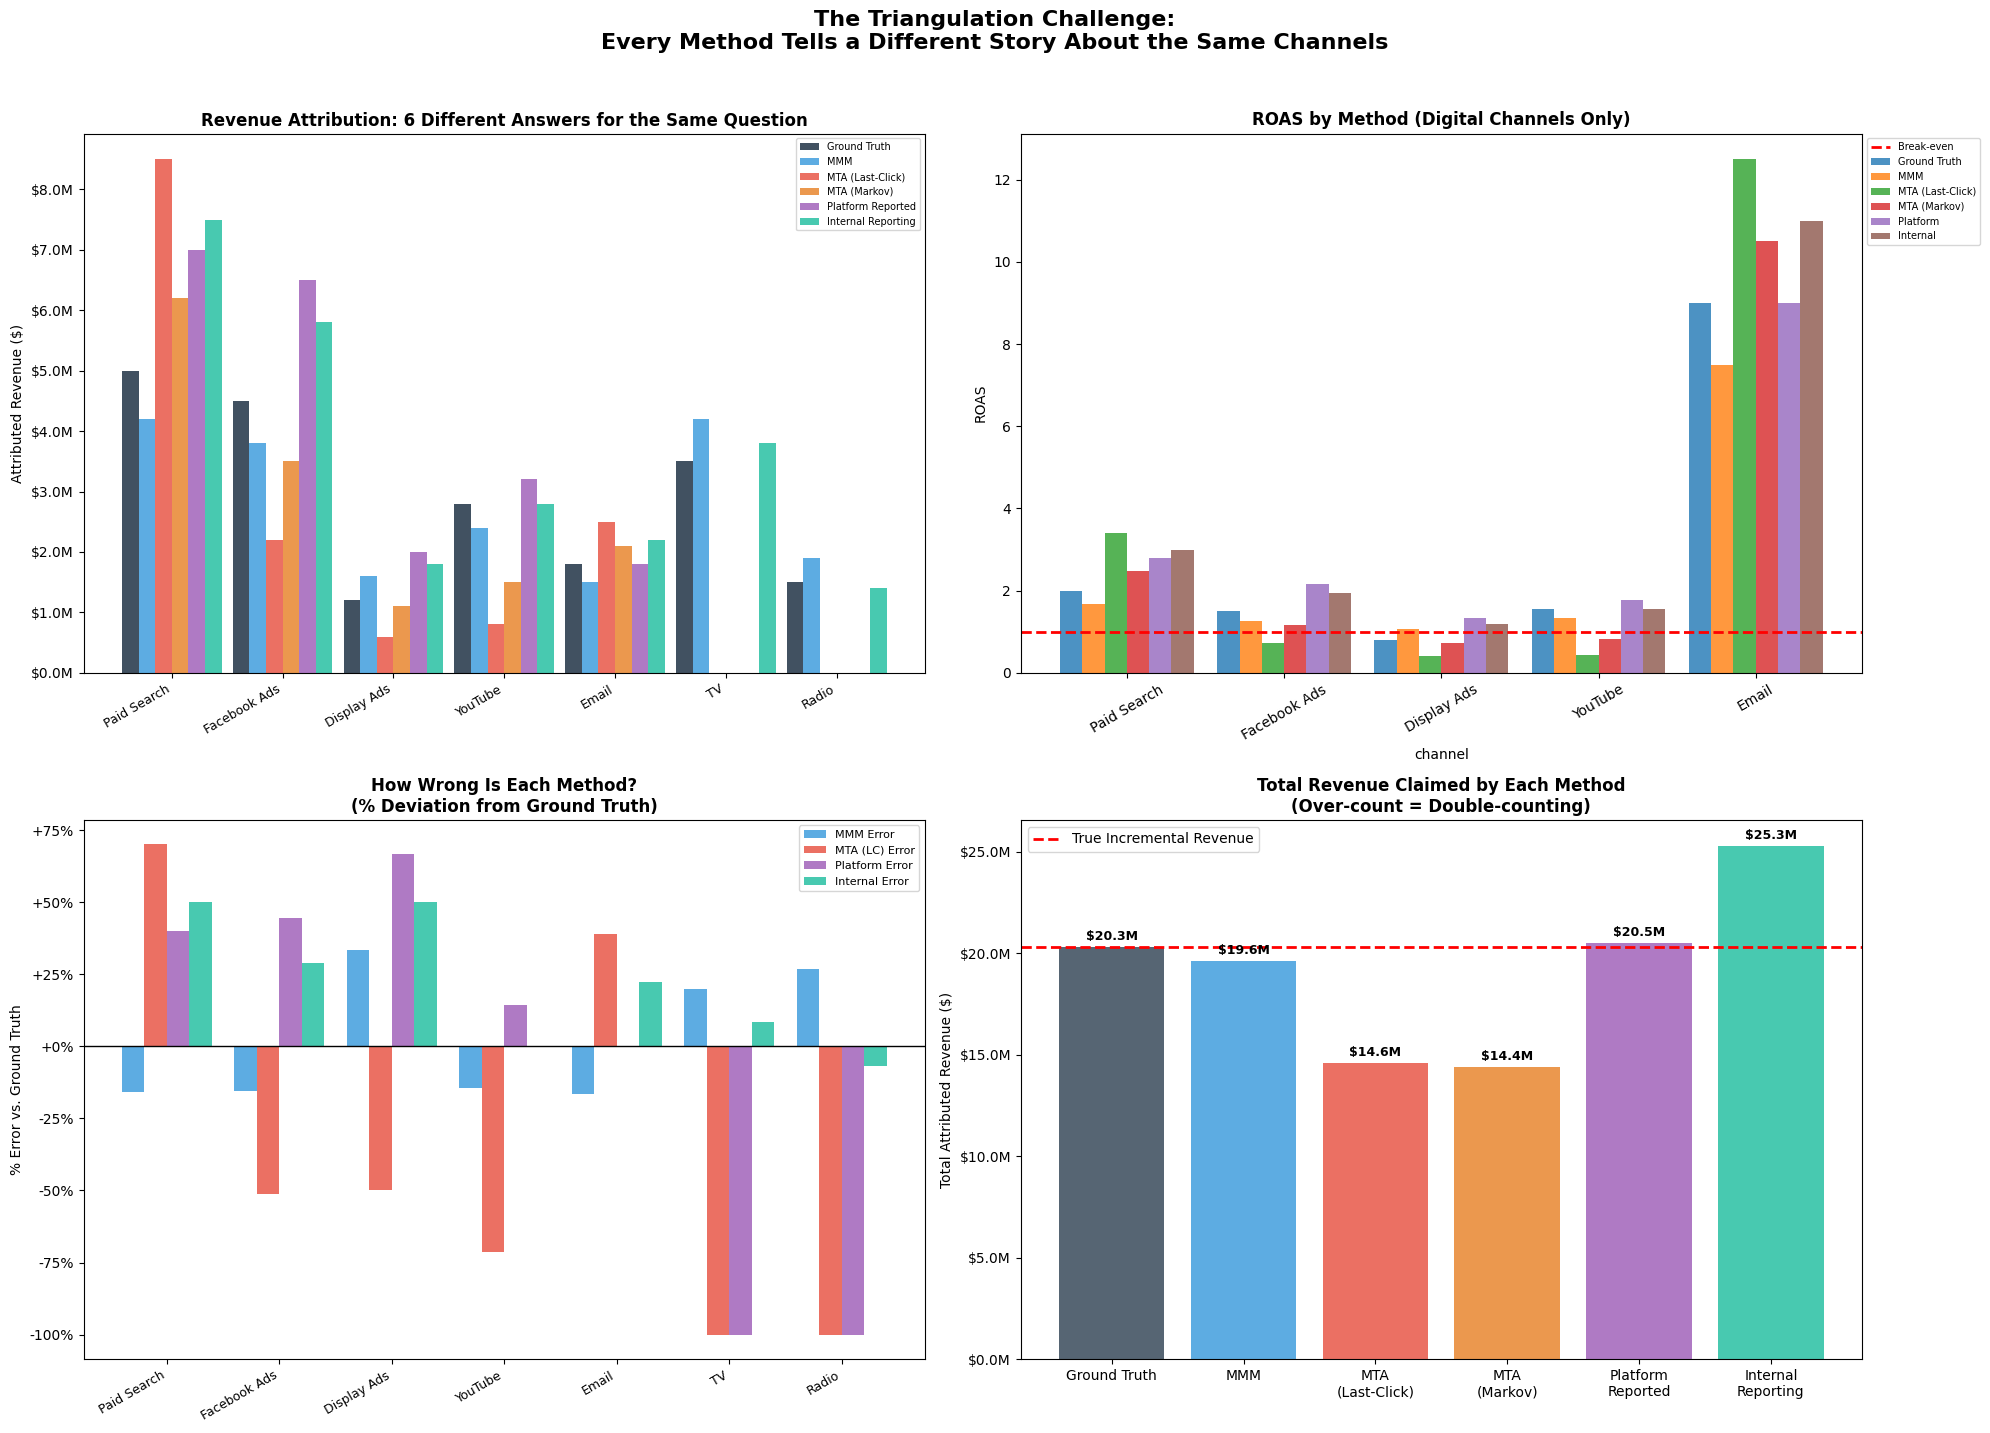


KEY OBSERVATIONS:
1. MTA assigns ZERO to TV and Radio (can't track offline channels)
2. Platforms OVER-REPORT dramatically (especially Paid Search & Facebook)
3. MMM tends to OVER-CREDIT TV (picks up correlated seasonality)
4. Internal reporting (dashboards) is closest to platforms but still biased
5. The SUM of platform-reported numbers exceeds total incremental revenue
   → This is the double-counting problem

No single method gets it right. That's why we need triangulation.



In [4]:
# ============================================================================
# MEGA VISUALIZATION: All Measurement Methods Side-by-Side
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('The Triangulation Challenge:\nEvery Method Tells a Different Story About the Same Channels',
             fontsize=16, fontweight='bold', y=1.02)

colors_map = {
    'Paid Search': '#4285F4', 'Facebook Ads': '#1877F2', 'Display Ads': '#FF9800',
    'YouTube': '#FF0000', 'Email': '#2ECC71', 'TV': '#9B59B6', 'Radio': '#E67E22'
}
ch_colors = [colors_map[c] for c in channels]

# --- Plot 1: Revenue Attribution by Source (Grouped Bar) ---
ax1 = axes[0, 0]
x = np.arange(len(channels))
width = 0.15

bars_truth = ax1.bar(x - 2.5*width, ground_truth['true_incremental_revenue'], width,
                     label='Ground Truth', color='#2c3e50', alpha=0.9)
bars_mmm = ax1.bar(x - 1.5*width, mmm_results['mmm_revenue'], width,
                   label='MMM', color='#3498db', alpha=0.8)
bars_mta_lc = ax1.bar(x - 0.5*width, mta_results['mta_last_click_rev'], width,
                      label='MTA (Last-Click)', color='#e74c3c', alpha=0.8)
bars_mta_mk = ax1.bar(x + 0.5*width, mta_results['mta_markov_rev'], width,
                      label='MTA (Markov)', color='#e67e22', alpha=0.8)
bars_platform = ax1.bar(x + 1.5*width, platform_results['platform_reported_rev'], width,
                        label='Platform Reported', color='#9b59b6', alpha=0.8)
bars_internal = ax1.bar(x + 2.5*width, internal_reporting['internal_reported_rev'], width,
                        label='Internal Reporting', color='#1abc9c', alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Attributed Revenue ($)')
ax1.set_title('Revenue Attribution: 6 Different Answers for the Same Question', fontweight='bold')
ax1.legend(fontsize=7, loc='upper right')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# --- Plot 2: ROAS by Method ---
ax2 = axes[0, 1]
roas_comparison = pd.DataFrame({
    'Ground Truth': ground_truth['true_incremental_revenue'] / ground_truth['spend'],
    'MMM': mmm_results['mmm_revenue'] / ground_truth['spend'],
    'MTA (Last-Click)': mta_results['mta_last_click_rev'] / ground_truth['spend'],
    'MTA (Markov)': mta_results['mta_markov_rev'] / ground_truth['spend'],
    'Platform': platform_results['platform_reported_rev'] / ground_truth['spend'],
    'Internal': internal_reporting['internal_reported_rev'] / ground_truth['spend'],
})
# Only show digital channels (where all methods have data)
digital_channels = ['Paid Search', 'Facebook Ads', 'Display Ads', 'YouTube', 'Email']
roas_comparison.loc[digital_channels].plot(kind='bar', ax=ax2, width=0.85, alpha=0.8)
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax2.set_ylabel('ROAS')
ax2.set_title('ROAS by Method (Digital Channels Only)', fontweight='bold')
ax2.legend(fontsize=7, bbox_to_anchor=(1.0, 1.0))
ax2.tick_params(axis='x', rotation=30)

# --- Plot 3: Error vs. Ground Truth ---
ax3 = axes[1, 0]
error_mmm = (mmm_results['mmm_revenue'] - ground_truth['true_incremental_revenue']) / ground_truth['true_incremental_revenue'] * 100
error_mta_lc = (mta_results['mta_last_click_rev'] - ground_truth['true_incremental_revenue']) / ground_truth['true_incremental_revenue'] * 100
error_platform = (platform_results['platform_reported_rev'] - ground_truth['true_incremental_revenue']) / ground_truth['true_incremental_revenue'] * 100
error_internal = (internal_reporting['internal_reported_rev'] - ground_truth['true_incremental_revenue']) / ground_truth['true_incremental_revenue'] * 100

x = np.arange(len(channels))
width = 0.2
ax3.bar(x - 1.5*width, error_mmm, width, label='MMM Error', color='#3498db', alpha=0.8)
ax3.bar(x - 0.5*width, error_mta_lc, width, label='MTA (LC) Error', color='#e74c3c', alpha=0.8)
ax3.bar(x + 0.5*width, error_platform, width, label='Platform Error', color='#9b59b6', alpha=0.8)
ax3.bar(x + 1.5*width, error_internal, width, label='Internal Error', color='#1abc9c', alpha=0.8)
ax3.axhline(y=0, color='black', linewidth=1)
ax3.set_xticks(x)
ax3.set_xticklabels(channels, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('% Error vs. Ground Truth')
ax3.set_title('How Wrong Is Each Method?\n(% Deviation from Ground Truth)', fontweight='bold')
ax3.legend(fontsize=8)
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:+.0f}%'))

# --- Plot 4: Sum of All Channel Credits (Double-Counting Check) ---
ax4 = axes[1, 1]
method_totals = {
    'Ground Truth': ground_truth['true_incremental_revenue'].sum(),
    'MMM': mmm_results['mmm_revenue'].sum(),
    'MTA\n(Last-Click)': mta_results['mta_last_click_rev'].sum(),
    'MTA\n(Markov)': mta_results['mta_markov_rev'].sum(),
    'Platform\nReported': platform_results['platform_reported_rev'].sum(),
    'Internal\nReporting': internal_reporting['internal_reported_rev'].sum(),
}

bar_colors = ['#2c3e50', '#3498db', '#e74c3c', '#e67e22', '#9b59b6', '#1abc9c']
bars = ax4.bar(method_totals.keys(), method_totals.values(), color=bar_colors, alpha=0.8)
ax4.axhline(y=ground_truth['true_incremental_revenue'].sum(), color='red', 
            linestyle='--', linewidth=2, label='True Incremental Revenue')
ax4.set_ylabel('Total Attributed Revenue ($)')
ax4.set_title('Total Revenue Claimed by Each Method\n(Over-count = Double-counting)', fontweight='bold')
ax4.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax4.legend()

for bar, val in zip(bars, method_totals.values()):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200000,
             f'${val/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
KEY OBSERVATIONS:
=================================================================
1. MTA assigns ZERO to TV and Radio (can't track offline channels)
2. Platforms OVER-REPORT dramatically (especially Paid Search & Facebook)
3. MMM tends to OVER-CREDIT TV (picks up correlated seasonality)
4. Internal reporting (dashboards) is closest to platforms but still biased
5. The SUM of platform-reported numbers exceeds total incremental revenue
   → This is the double-counting problem

No single method gets it right. That's why we need triangulation.
""")

---

# Section 4: How MMM and MTA Relate — A Deep Mapping

## 4.1 Same Channels, Different Lenses

MMM and MTA are measuring the **same underlying reality** but through fundamentally different lenses:

### MMM Perspective: "Channel → Sales (Aggregate)"
- Input: Weekly spend by channel
- Output: Estimated **marginal contribution** of each channel to total sales
- Mechanism: Regression on aggregate time series with adstock + saturation
- Time scale: Weeks to months
- Captures: Long-term brand effects, offline channels, carryover

### MTA Perspective: "Touchpoint → Conversion (Individual)"
- Input: User-level journey data (click/view sequences)
- Output: **Credit allocation** for each touchpoint in a converting journey
- Mechanism: Path analysis, Markov chains, Shapley values, ML models
- Time scale: Hours to days (within attribution window)
- Captures: Short-term direct response, creative-level performance, sequencing

## 4.2 Where They Agree vs. Disagree

Typically, MMM and MTA will **agree** on:
- ✅ Relative ranking of very high-performing vs. very low-performing channels
- ✅ Directional recommendations (if both say "increase Facebook", trust it)
- ✅ Channels with clean, direct-response signals (e.g., branded paid search)

They will commonly **disagree** on:
- ❌ The exact magnitude of each channel's contribution
- ❌ Upper-funnel channels (TV, YouTube) — MMM sees these; MTA often can't
- ❌ Lower-funnel channels (Search, Email) — MTA over-credits; MMM may under-credit
- ❌ Display/Programmatic — MTA sees view-throughs; MMM sees spend correlation (both noisy)

## 4.3 The Funnel Geometry of Disagreement


                    ┌────────────────────────────┐
                    │     AWARENESS / TOP        │ ← MMM captures well
                    │ (TV, YouTube, Social Video)│ ← MTA misses or under-credits
                    ├────────────────────────────┤
                    │     CONSIDERATION / MID    │ ← Both partially capture
                    │  (Display, Social, Content)│ ← Both are noisy here
                    ├────────────────────────────┤
                    │     CONVERSION / BOTTOM    │ ← MTA captures well
                    │  (Search, Email, Retarget) │ ← MMM may under-credit
                    └────────────────────────────┘


**Rule of thumb**: MMM is more trustworthy for upper-funnel, MTA for lower-funnel. The middle funnel is where both struggle and experiments are most needed.

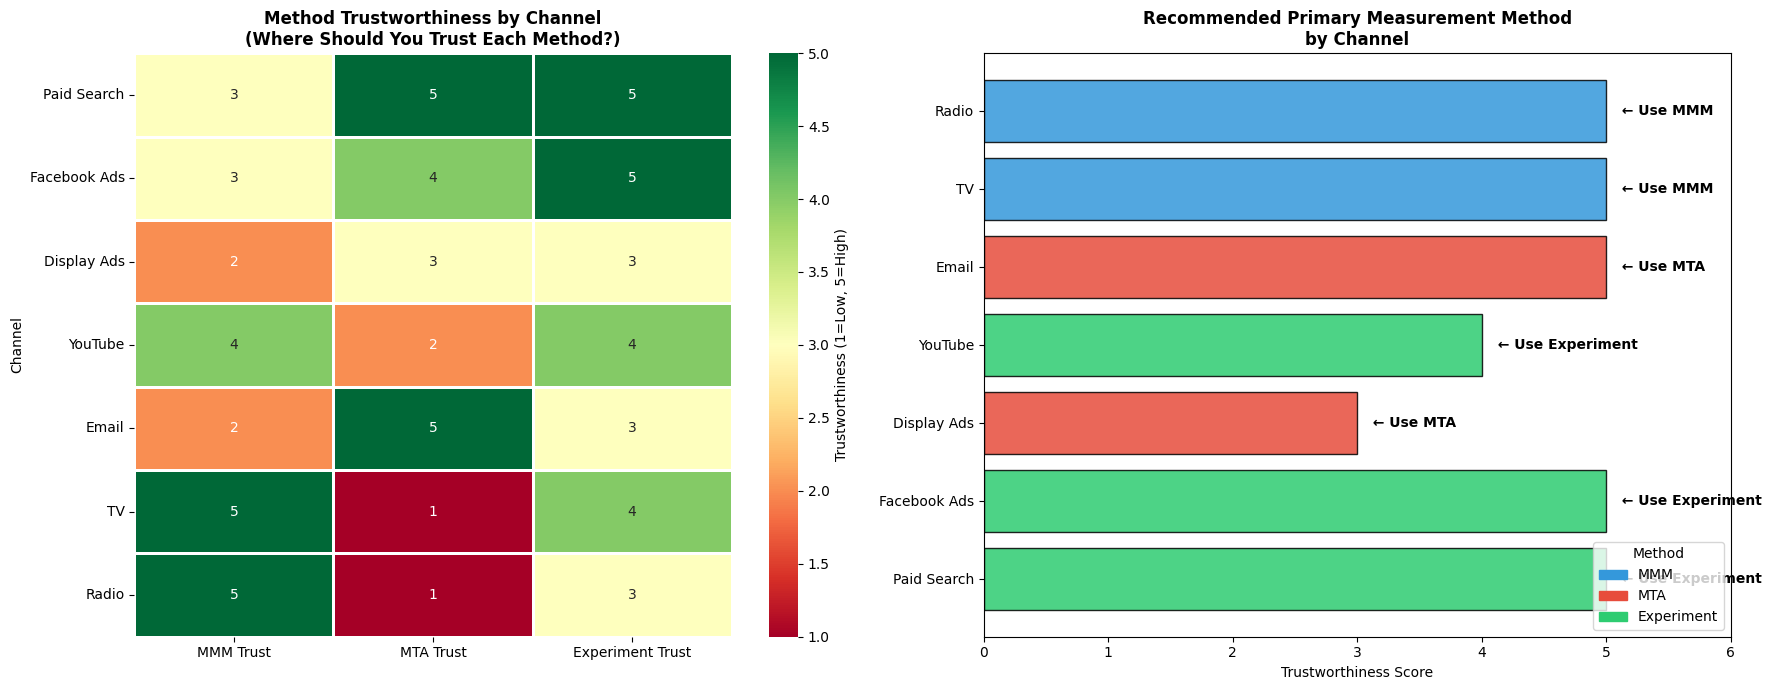


PRACTICAL GUIDANCE:
• Paid Search → Trust experiments (geo-lift) or MTA; MMM struggles
  with search because spend often correlates with demand

• Facebook Ads → Trust experiments (Conv Lift) first; MTA under-credits
  due to iOS tracking loss; MMM is reasonable but noisy

• Display Ads → All methods are weak here; be cautious with any number

• YouTube → MMM captures brand effect better than MTA;
  Brand Lift studies are gold standard

• Email → MTA captures direct response well; MMM often under-credits

• TV → Only MMM can measure this; validate with brand lift if possible

• Radio → Only MMM can measure this; highest uncertainty



In [5]:
# ============================================================================
# FUNNEL-POSITION ANALYSIS: Where Each Method Is Most/Least Trustworthy
# ============================================================================

funnel_trust = pd.DataFrame({
    'Channel': channels,
    'Funnel Position': ['Lower', 'Mid', 'Mid', 'Upper', 'Lower', 'Upper', 'Upper'],
    'MMM Trust': [3, 3, 2, 4, 2, 5, 5],          # 1-5 scale
    'MTA Trust': [5, 4, 3, 2, 5, 1, 1],           # 1-5 scale
    'Experiment Trust': [5, 5, 3, 4, 3, 4, 3],    # 1-5 scale (if available)
    'Experiment Available': [True, True, False, True, False, False, False],
}).set_index('Channel')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Trust Heatmap ---
ax1 = axes[0]
trust_cols = ['MMM Trust', 'MTA Trust', 'Experiment Trust']
trust_data = funnel_trust[trust_cols]
sns.heatmap(trust_data, annot=True, cmap='RdYlGn', center=3, ax=ax1,
            linewidths=1, vmin=1, vmax=5, fmt='d',
            cbar_kws={'label': 'Trustworthiness (1=Low, 5=High)'})
ax1.set_title('Method Trustworthiness by Channel\n(Where Should You Trust Each Method?)', 
              fontweight='bold')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# --- Plot 2: Recommended Primary Method by Channel ---
ax2 = axes[1]
# For each channel, pick the best method
best_method = []
for ch in channels:
    row = funnel_trust.loc[ch]
    if row['Experiment Available'] and row['Experiment Trust'] >= 4:
        best_method.append('Experiment')
    elif row['MMM Trust'] > row['MTA Trust']:
        best_method.append('MMM')
    else:
        best_method.append('MTA')

method_colors = {'MMM': '#3498db', 'MTA': '#e74c3c', 'Experiment': '#2ecc71'}
bar_colors = [method_colors[m] for m in best_method]

ax2.barh(channels, [funnel_trust.loc[ch, f'{best_method[i]} Trust'] 
                     for i, ch in enumerate(channels)],
         color=bar_colors, alpha=0.85, edgecolor='black')

# Add method labels
for i, (ch, method) in enumerate(zip(channels, best_method)):
    trust_val = funnel_trust.loc[ch, f'{method} Trust']
    ax2.text(trust_val + 0.05, i, f'  ← Use {method}', va='center', fontsize=10, fontweight='bold')

ax2.set_xlabel('Trustworthiness Score')
ax2.set_title('Recommended Primary Measurement Method\nby Channel', fontweight='bold')
ax2.set_xlim(0, 6)

# Legend
legend_patches = [mpatches.Patch(color=c, label=m) for m, c in method_colors.items()]
ax2.legend(handles=legend_patches, title='Method', loc='lower right')

plt.tight_layout()
plt.show()

print("""
PRACTICAL GUIDANCE:
=================================================================
• Paid Search → Trust experiments (geo-lift) or MTA; MMM struggles
  with search because spend often correlates with demand
  
• Facebook Ads → Trust experiments (Conv Lift) first; MTA under-credits
  due to iOS tracking loss; MMM is reasonable but noisy
  
• Display Ads → All methods are weak here; be cautious with any number
  
• YouTube → MMM captures brand effect better than MTA;
  Brand Lift studies are gold standard
  
• Email → MTA captures direct response well; MMM often under-credits
  
• TV → Only MMM can measure this; validate with brand lift if possible
  
• Radio → Only MMM can measure this; highest uncertainty
""")

---

# Section 5: Calibrating MMM with Incrementality Experiments

## 5.1 Why Calibration Is the Most Valuable Thing You Can Do

An MMM model without experimental calibration is just a **sophisticated guess**. Calibration uses experimental results (ground truth on specific channels) to:

1. **Anchor** the model — if the experiment says Facebook ROAS = 1.5, the MMM's estimate should be near that
2. **Set informative Bayesian priors** — use experiment results to constrain the posterior distribution
3. **Detect model misspecification** — if the MMM is wildly off from experiment results, something is wrong
4. **Build credibility** — stakeholders trust "MMM calibrated with experiments" far more than "MMM alone"

## 5.2 The Bayesian Calibration Approach

In a Bayesian MMM, each channel has a coefficient $\beta_c$ with a prior distribution:

$$\beta_c \sim \text{Prior}(\mu_c, \sigma_c)$$

**Without calibration**, we set vague priors: $\beta_c \sim \text{HalfNormal}(\sigma=\text{large})$

**With calibration**, we use experiment results to set informative priors:

$$\beta_c \sim \mathcal{N}(\hat{\theta}_{c}^{EXP}, \hat{\sigma}_{c}^{EXP})$$

Where $\hat{\theta}_{c}^{EXP}$ is the experiment-estimated channel effect and $\hat{\sigma}_{c}^{EXP}$ captures the uncertainty.

## 5.3 Practical Calibration Steps

1. **Run an incrementality experiment** on target channel (geo-lift, conv lift, etc.)
2. **Estimate the incremental revenue/conversions** with confidence interval
3. **Translate to the MMM's units** (e.g., if MMM uses spend-to-sales coefficients, convert experiment results to the same scale)
4. **Set the prior** for that channel's coefficient using the experiment result
5. **Refit the MMM** — the calibrated channel should now be more accurate
6. **Check if other channels shifted** — calibrating one channel can change others (the budget must be allocated from somewhere)

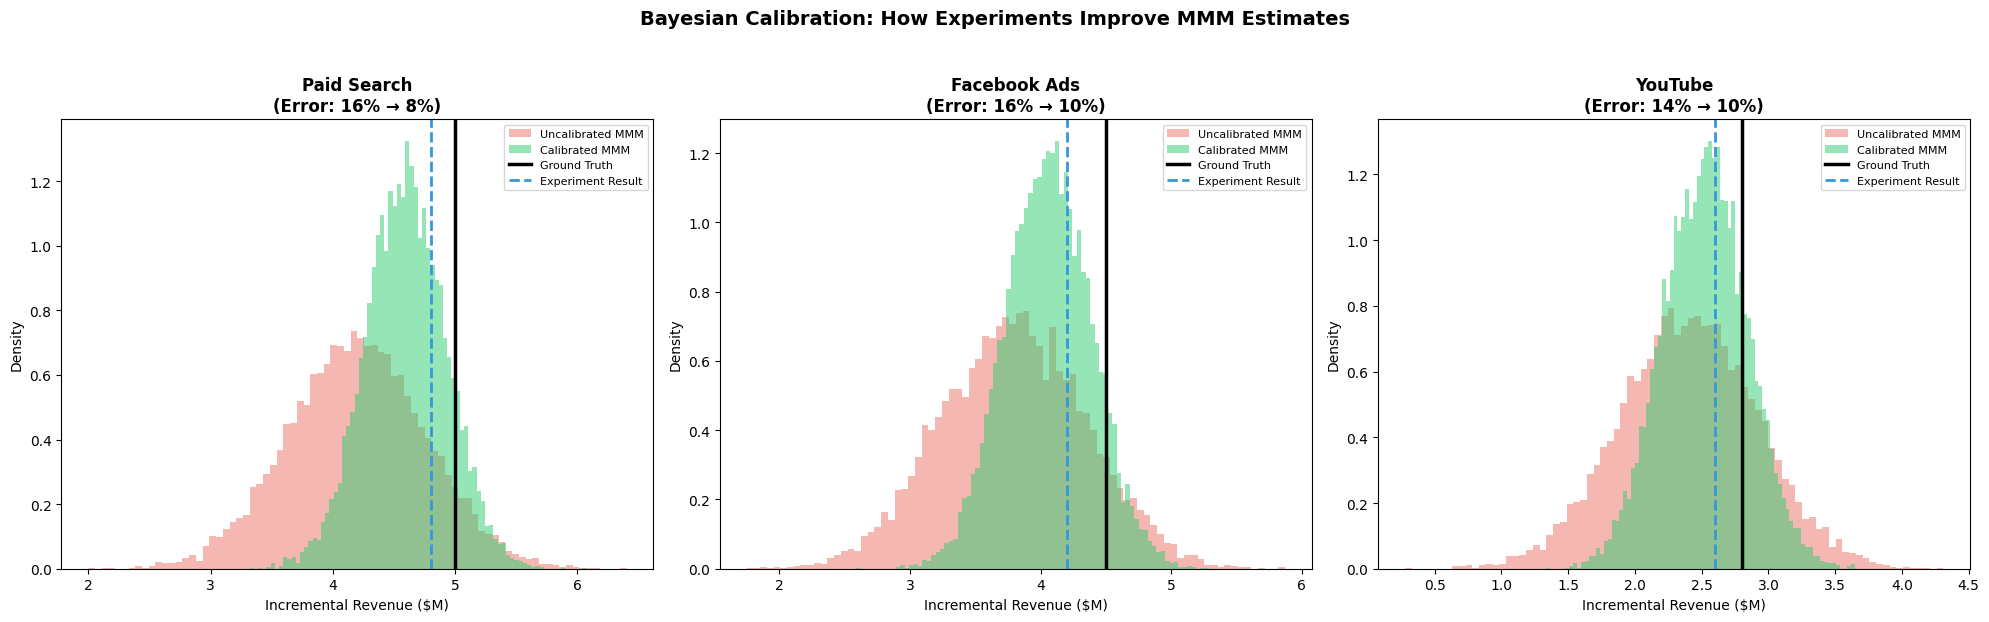

 CALIBRATION IMPACT SUMMARY

Channel              True Rev   Uncal. Est     Cal. Est  Error Before  Error After  Improved?
---------------------------------------------------------------------------------------
  Paid Search    $      5.0M $      4.2M $      4.6M        16.0%        8.2%      ✓ YES
  Facebook Ads   $      4.5M $      3.8M $      4.1M        15.6%        9.7%      ✓ YES
  Display Ads    $      1.2M $      1.6M $      1.6M        33.3%       33.3%      — N/A
  YouTube        $      2.8M $      2.4M $      2.5M        14.3%        9.9%      ✓ YES
  Email          $      1.8M $      1.5M $      1.5M        16.7%       16.7%      — N/A
  TV             $      3.5M $      4.2M $      4.2M        20.0%       20.0%      — N/A
  Radio          $      1.5M $      1.9M $      1.9M        26.7%       26.7%      — N/A


KEY TAKEAWAYS:
• Calibrated channels move CLOSER to ground truth (lower error)
• The posterior is TIGHTER (higher confidence) after calibration
• Uncalibrated chann

In [6]:
# ============================================================================
# CALIBRATION SIMULATION: Before vs. After Experiment-Informed Priors
# ============================================================================

def simulate_bayesian_calibration(ground_truth, mmm_results, experiment_results, 
                                  n_samples=10000):
    """
    Simulate how Bayesian calibration shifts MMM estimates toward 
    experiment-validated ground truth.
    
    We model each channel's estimated revenue contribution as coming from
    a posterior distribution. Calibration tightens the posterior around
    the experiment result.
    """
    np.random.seed(42)
    
    results = {}
    
    for channel in ground_truth.index:
        true_rev = ground_truth.loc[channel, 'true_incremental_revenue']
        mmm_rev = mmm_results.loc[channel, 'mmm_revenue']
        mmm_ci_lower = mmm_results.loc[channel, 'mmm_ci_lower']
        mmm_ci_upper = mmm_results.loc[channel, 'mmm_ci_upper']
        
        # UN-CALIBRATED posterior: centered on MMM estimate with wide uncertainty
        uncalibrated_mean = mmm_rev
        uncalibrated_std = (mmm_ci_upper - mmm_ci_lower) / (2 * 1.96)
        uncalibrated_posterior = np.random.normal(uncalibrated_mean, uncalibrated_std, n_samples)
        
        # CALIBRATED posterior: if we have an experiment, shift toward experiment result
        if channel in experiment_results.index:
            exp_rev = experiment_results.loc[channel, 'exp_incremental_rev']
            exp_ci_lower = experiment_results.loc[channel, 'exp_ci_lower']
            exp_ci_upper = experiment_results.loc[channel, 'exp_ci_upper']
            exp_std = (exp_ci_upper - exp_ci_lower) / (2 * 1.96)
            
            # Bayesian update: combine MMM prior with experiment likelihood
            # Posterior precision = prior precision + likelihood precision
            prior_precision = 1.0 / (uncalibrated_std ** 2)
            likelihood_precision = 1.0 / (exp_std ** 2)
            posterior_precision = prior_precision + likelihood_precision
            
            # Posterior mean = weighted average
            calibrated_mean = (prior_precision * uncalibrated_mean + 
                              likelihood_precision * exp_rev) / posterior_precision
            calibrated_std = 1.0 / np.sqrt(posterior_precision)
            
            calibrated_posterior = np.random.normal(calibrated_mean, calibrated_std, n_samples)
            has_experiment = True
        else:
            calibrated_posterior = uncalibrated_posterior  # No change
            calibrated_mean = uncalibrated_mean
            calibrated_std = uncalibrated_std
            has_experiment = False
        
        results[channel] = {
            'true_rev': true_rev,
            'mmm_rev': mmm_rev,
            'uncalibrated_posterior': uncalibrated_posterior,
            'calibrated_posterior': calibrated_posterior,
            'uncalibrated_mean': uncalibrated_mean,
            'calibrated_mean': calibrated_mean,
            'uncalibrated_std': uncalibrated_std,
            'calibrated_std': calibrated_std,
            'has_experiment': has_experiment,
            'uncal_error': abs(uncalibrated_mean - true_rev) / true_rev * 100,
            'cal_error': abs(calibrated_mean - true_rev) / true_rev * 100,
        }
    
    return results

calibration_results = simulate_bayesian_calibration(
    ground_truth, mmm_results, experiment_results
)

# ============================================================================
# VISUALIZE: The Power of Calibration
# ============================================================================

# Show posterior distributions for the 3 calibrated channels
calibrated_channels = ['Paid Search', 'Facebook Ads', 'YouTube']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Bayesian Calibration: How Experiments Improve MMM Estimates',
             fontsize=14, fontweight='bold', y=1.03)

for ax, channel in zip(axes, calibrated_channels):
    r = calibration_results[channel]
    
    # Plot uncalibrated posterior
    ax.hist(r['uncalibrated_posterior'] / 1e6, bins=80, alpha=0.4, density=True,
            color='#e74c3c', label='Uncalibrated MMM')
    
    # Plot calibrated posterior
    ax.hist(r['calibrated_posterior'] / 1e6, bins=80, alpha=0.5, density=True,
            color='#2ecc71', label='Calibrated MMM')
    
    # True value
    ax.axvline(x=r['true_rev'] / 1e6, color='black', linewidth=2.5, 
               linestyle='-', label='Ground Truth')
    
    # Experiment estimate
    exp_rev = experiment_results.loc[channel, 'exp_incremental_rev']
    ax.axvline(x=exp_rev / 1e6, color='#3498db', linewidth=2, 
               linestyle='--', label='Experiment Result')
    
    ax.set_xlabel('Incremental Revenue ($M)')
    ax.set_ylabel('Density')
    ax.set_title(f'{channel}\n(Error: {r["uncal_error"]:.0f}% → {r["cal_error"]:.0f}%)',
                 fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
print("=" * 80)
print(" CALIBRATION IMPACT SUMMARY")
print("=" * 80)
print(f"\n{'Channel':<16s} {'True Rev':>12s} {'Uncal. Est':>12s} {'Cal. Est':>12s} "
      f"{'Error Before':>13s} {'Error After':>12s} {'Improved?':>10s}")
print("-" * 87)

for channel in ground_truth.index:
    r = calibration_results[channel]
    improved = '✓ YES' if r['cal_error'] < r['uncal_error'] else '✗ NO'
    if not r['has_experiment']:
        improved = '— N/A'
    print(f"  {channel:<14s} ${r['true_rev']/1e6:>9.1f}M ${r['uncalibrated_mean']/1e6:>9.1f}M "
          f"${r['calibrated_mean']/1e6:>9.1f}M {r['uncal_error']:>11.1f}% "
          f"{r['cal_error']:>10.1f}% {improved:>10s}")

print(f"""
\nKEY TAKEAWAYS:
{'='*60}
• Calibrated channels move CLOSER to ground truth (lower error)
• The posterior is TIGHTER (higher confidence) after calibration
• Uncalibrated channels are unchanged — you need experiments on
  EACH channel you want to calibrate
• Even 1-2 experiments per year dramatically improve your MMM
• This is the #1 most impactful thing a measurement team can do
""")

---

# Section 6: When the Model Doesn't Align with Internal Reporting

## 6.1 This WILL Happen. Here's Why.

If you build an MMM or a custom MTA model, your numbers **will** disagree with:
- Google Ads dashboard
- Meta Ads Manager
- Your internal BI dashboard (Tableau, Looker, Mode)
- The marketing team's "standard" numbers

This isn't a bug — it's a feature. But navigating the disagreement is the hardest soft-skill challenge a data scientist faces.

## 6.2 The 10 Most Common Reasons for Misalignment

| # | Reason | Direction of Impact | How to Diagnose |
|---|--------|-------------------|-----------------|
| 1 | **Platform double-counting** | Platform over-reports | Sum platform totals; if > actual conversions, they're double-counting |
| 2 | **Different attribution windows** | Longer window = more conversions | Compare same-window results (e.g., 7-day click everywhere) |
| 3 | **View-through vs. click-only** | View-throughs inflate Display/Video/Social | Run click-only attribution and compare |
| 4 | **iOS tracking loss** | Social/programmatic under-reported in your data, but Meta models them back | Compare pre/post iOS 14.5 volumes |
| 5 | **Modeled conversions** | Platforms add "estimated" conversions | Check platform settings; they now mix modeled + observed |
| 6 | **Different conversion definitions** | Direct comparison impossible | Align on same event definition across all systems |
| 7 | **Different time periods** | Off by days/weeks | Ensure exact date range matching |
| 8 | **MMM aggregation bias** | MMM smooths out weekly variation | Compare at same time granularity |
| 9 | **MMM captures carryover, MTA doesn't** | MMM assigns more credit to channels with carryover | Check adstock parameters — high decay = more carryover revenue |
| 10 | **Omitted variable bias in MMM** | MMM misattributes to correlated channels | Check for confounders (was TV spend correlated with promotions?) |

## 6.3 Diagnostic Framework: The "Source of Truth Ladder"

When numbers disagree, use this hierarchy to determine which source to trust:

```
Most Trustworthy
    │
    ├── 1. Well-designed RCT / Geo-lift experiment
    │       → Gold standard. If an experiment says X, trust it.
    │
    ├── 2. MMM calibrated with experiments
    │       → Best "always-on" estimate grounded in causal evidence
    │
    ├── 3. Uncalibrated MMM
    │       → Good for relative rankings, less reliable for absolute values
    │
    ├── 4. Algorithmic MTA (Markov/Shapley) with deduplication
    │       → Data-driven but subject to tracking gaps
    │
    ├── 5. Rule-based MTA (last-click, linear)
    │       → Simple, biased, but at least consistent
    │
    ├── 6. Platform self-reported numbers
    │       → Biased by design (each platform gives itself maximum credit)
    │
    └── 7. Anecdotal / "we've always done it this way"
            → Least reliable but often the baseline you're replacing
Least Trustworthy
```

In [7]:
# ============================================================================
# DIAGNOSIS TOOL: Systematic Misalignment Analysis
# ============================================================================

def diagnose_misalignment(ground_truth, mmm_results, mta_results, 
                          platform_results, internal_reporting, experiment_results):
    """
    Systematically identify and diagnose why models disagree with internal reporting.
    
    For each channel, flag the type and severity of misalignment,
    and recommend a resolution path.
    """
    
    diagnostics = []
    
    for channel in ground_truth.index:
        true_rev = ground_truth.loc[channel, 'true_incremental_revenue']
        spend = ground_truth.loc[channel, 'spend']
        mmm_rev = mmm_results.loc[channel, 'mmm_revenue']
        mmm_lower = mmm_results.loc[channel, 'mmm_ci_lower']
        mmm_upper = mmm_results.loc[channel, 'mmm_ci_upper']
        mta_lc = mta_results.loc[channel, 'mta_last_click_rev']
        platform_rev = platform_results.loc[channel, 'platform_reported_rev']
        internal_rev = internal_reporting.loc[channel, 'internal_reported_rev']
        
        # Check if experiment exists
        has_experiment = channel in experiment_results.index
        exp_rev = experiment_results.loc[channel, 'exp_incremental_rev'] if has_experiment else None
        
        # ---- DIAGNOSE SPECIFIC ISSUES ----
        issues = []
        severity = 0  # 0-5 scale
        
        # Issue 1: MMM vs Internal Reporting gap
        mmm_vs_internal_pct = (mmm_rev - internal_rev) / internal_rev * 100
        if abs(mmm_vs_internal_pct) > 30:
            issues.append(f"MMM vs Internal gap: {mmm_vs_internal_pct:+.0f}%")
            severity += 2
        elif abs(mmm_vs_internal_pct) > 15:
            issues.append(f"MMM vs Internal gap: {mmm_vs_internal_pct:+.0f}% (moderate)")
            severity += 1
        
        # Issue 2: Platform over-reporting
        if platform_rev > 0:
            platform_vs_mmm = (platform_rev - mmm_rev) / mmm_rev * 100
            if platform_vs_mmm > 50:
                issues.append(f"Platform over-reports by {platform_vs_mmm:.0f}% vs MMM")
                severity += 2
        
        # Issue 3: MTA can't see channel (offline)
        if mta_lc == 0 and spend > 0:
            issues.append("MTA has ZERO visibility (offline channel)")
            severity += 1
        
        # Issue 4: MMM confidence interval is very wide
        ci_width = (mmm_upper - mmm_lower) / mmm_rev * 100
        if ci_width > 100:
            issues.append(f"MMM CI is very wide ({ci_width:.0f}% of estimate)")
            severity += 1
        
        # Issue 5: Last-click dramatically over-credits
        if mta_lc > 0:
            lc_vs_mmm = (mta_lc - mmm_rev) / mmm_rev * 100
            if lc_vs_mmm > 60:
                issues.append(f"Last-click over-credits by {lc_vs_mmm:.0f}% (closer bias)")
                severity += 1
        
        # ---- RESOLUTION RECOMMENDATION ----
        if has_experiment:
            resolution = f"CALIBRATE MMM with {experiment_results.loc[channel, 'exp_method']} result"
            confidence = "HIGH"
        elif severity >= 3:
            resolution = "RUN EXPERIMENT (geo-lift or conv lift recommended)"
            confidence = "LOW"
        elif abs(mmm_vs_internal_pct) < 15:
            resolution = "Acceptable alignment — monitor and present MMM with CI"
            confidence = "MODERATE"
        else:
            resolution = "Investigate: check attribution windows, tracking, and confounders"
            confidence = "MODERATE"
        
        diagnostics.append({
            'channel': channel,
            'mmm_rev': mmm_rev,
            'internal_rev': internal_rev,
            'gap_pct': mmm_vs_internal_pct,
            'severity': severity,
            'issues': '; '.join(issues) if issues else 'No major issues',
            'resolution': resolution,
            'confidence': confidence,
            'has_experiment': has_experiment,
        })
    
    return pd.DataFrame(diagnostics).set_index('channel')


# Run diagnosis
diagnostics = diagnose_misalignment(
    ground_truth, mmm_results, mta_results, 
    platform_results, internal_reporting, experiment_results
)

# Display results
print("=" * 100)
print(" MISALIGNMENT DIAGNOSTIC REPORT")
print(" MMM Model vs. Internal Reporting (Marketing Dashboards)")
print("=" * 100)

for channel, row in diagnostics.iterrows():
    severity_indicator = '🟢' if row['severity'] <= 1 else ('🟡' if row['severity'] <= 2 else '🔴')
    
    print(f"\n{severity_indicator} {channel}")
    print(f"  {'MMM Estimate:':<25s} ${row['mmm_rev']:>12,.0f}")
    print(f"  {'Internal Reporting:':<25s} ${row['internal_rev']:>12,.0f}")
    print(f"  {'Gap:':<25s} {row['gap_pct']:>+11.1f}%")
    print(f"  {'Severity:':<25s} {row['severity']}/5")
    print(f"  {'Issues:':<25s} {row['issues']}")
    print(f"  {'Confidence:':<25s} {row['confidence']}")
    print(f"  {'Resolution:':<25s} {row['resolution']}")

 MISALIGNMENT DIAGNOSTIC REPORT
 MMM Model vs. Internal Reporting (Marketing Dashboards)

🔴 Paid Search
  MMM Estimate:             $   4,200,000
  Internal Reporting:       $   7,500,000
  Gap:                            -44.0%
  Severity:                 5/5
  Issues:                   MMM vs Internal gap: -44%; Platform over-reports by 67% vs MMM; Last-click over-credits by 102% (closer bias)
  Confidence:               HIGH
  Resolution:               CALIBRATE MMM with Geo-lift result

🔴 Facebook Ads
  MMM Estimate:             $   3,800,000
  Internal Reporting:       $   5,800,000
  Gap:                            -34.5%
  Severity:                 4/5
  Issues:                   MMM vs Internal gap: -34%; Platform over-reports by 71% vs MMM
  Confidence:               HIGH
  Resolution:               CALIBRATE MMM with Conversion Lift result

🟢 Display Ads
  MMM Estimate:             $   1,600,000
  Internal Reporting:       $   1,800,000
  Gap:                            -11.1

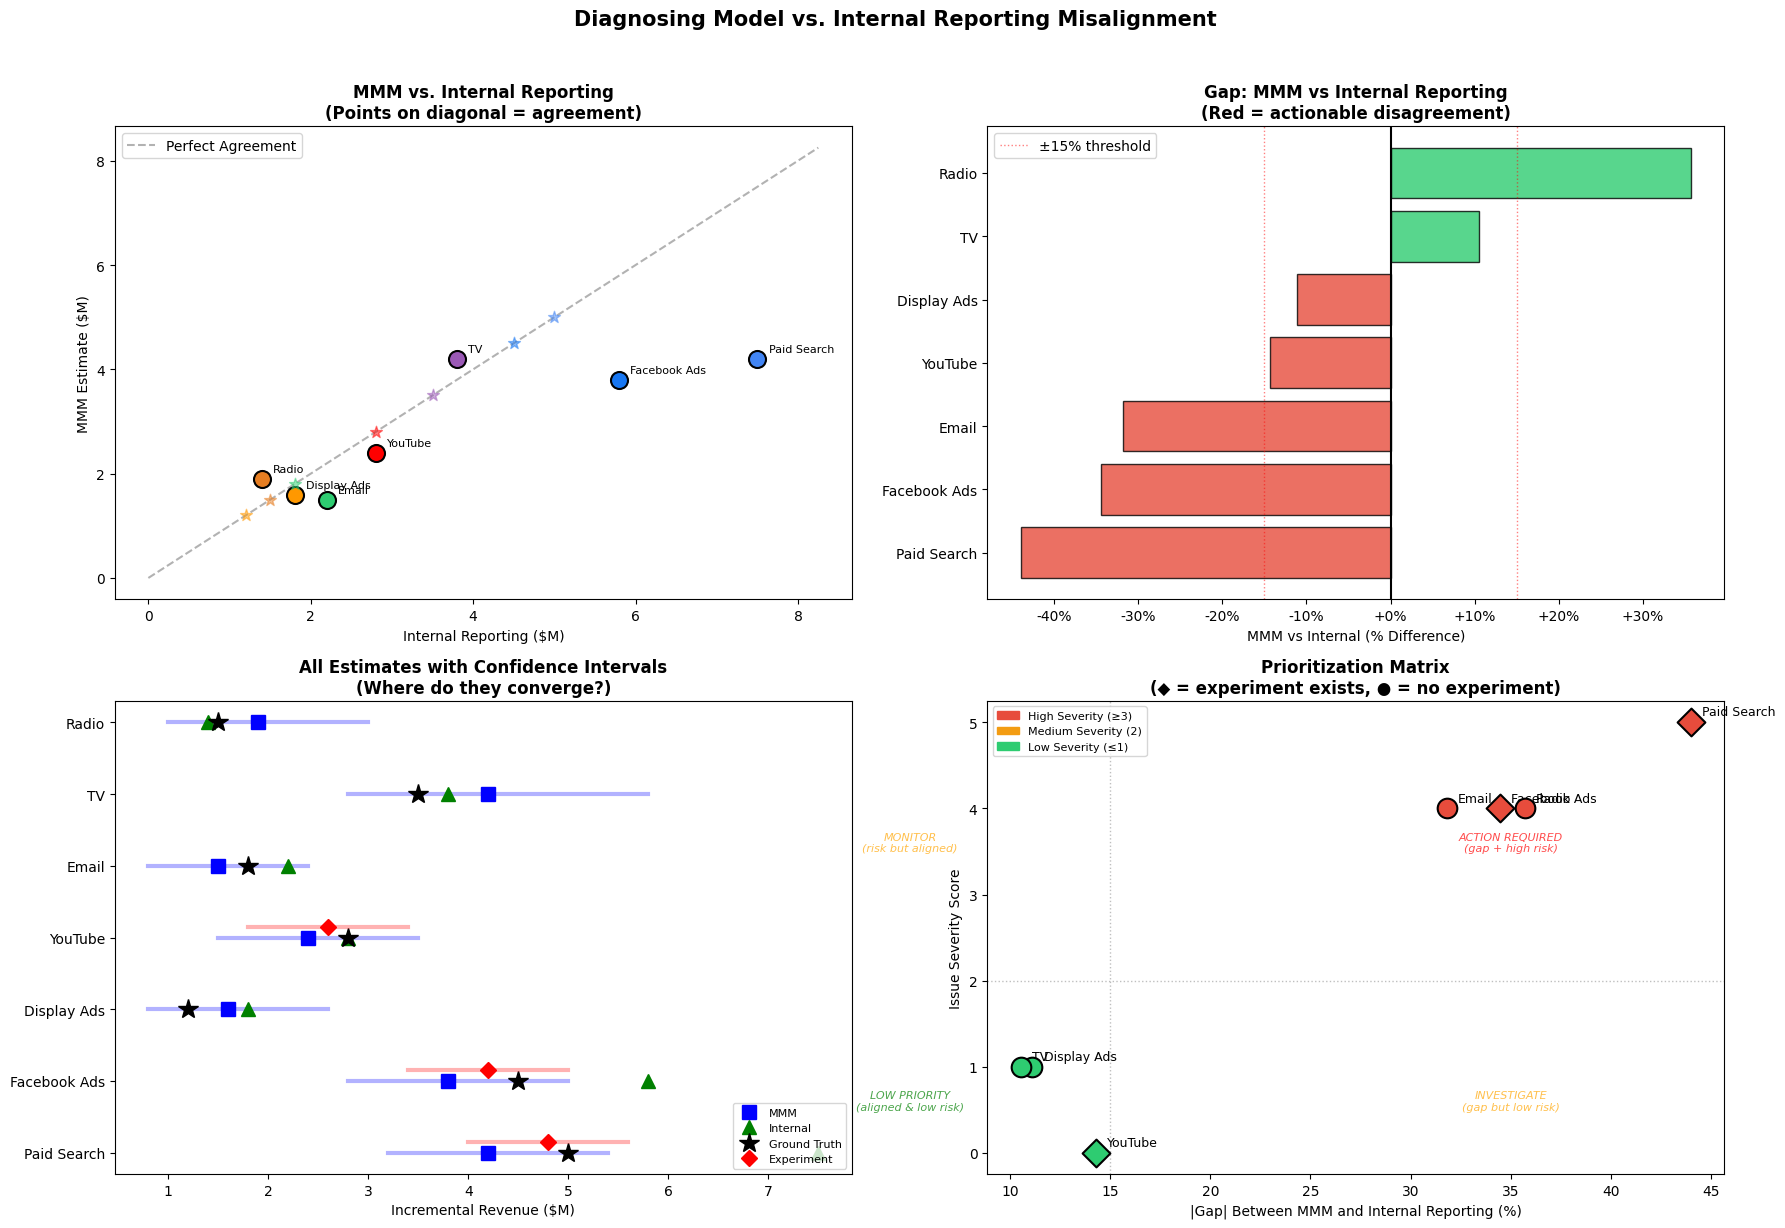

In [8]:
# ============================================================================
# VISUALIZE: The Misalignment Landscape
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Diagnosing Model vs. Internal Reporting Misalignment',
             fontsize=15, fontweight='bold', y=1.02)

# --- Plot 1: MMM vs Internal Reporting (Scatter) ---
ax1 = axes[0, 0]
colors_map = {
    'Paid Search': '#4285F4', 'Facebook Ads': '#1877F2', 'Display Ads': '#FF9800',
    'YouTube': '#FF0000', 'Email': '#2ECC71', 'TV': '#9B59B6', 'Radio': '#E67E22'
}

for channel in ground_truth.index:
    mmm_val = mmm_results.loc[channel, 'mmm_revenue'] / 1e6
    internal_val = internal_reporting.loc[channel, 'internal_reported_rev'] / 1e6
    true_val = ground_truth.loc[channel, 'true_incremental_revenue'] / 1e6
    
    ax1.scatter(internal_val, mmm_val, s=150, c=colors_map[channel], 
                edgecolors='black', linewidth=1.5, zorder=5)
    ax1.annotate(channel, (internal_val, mmm_val), 
                textcoords="offset points", xytext=(8, 5), fontsize=8)
    
    # Draw line to ground truth
    ax1.scatter(true_val, true_val, s=80, c=colors_map[channel], 
                marker='*', zorder=6, alpha=0.5)

# Perfect agreement line
max_val = max(internal_reporting['internal_reported_rev'].max(),
              mmm_results['mmm_revenue'].max()) / 1e6
ax1.plot([0, max_val*1.1], [0, max_val*1.1], 'k--', alpha=0.3, label='Perfect Agreement')
ax1.set_xlabel('Internal Reporting ($M)')
ax1.set_ylabel('MMM Estimate ($M)')
ax1.set_title('MMM vs. Internal Reporting\n(Points on diagonal = agreement)', fontweight='bold')
ax1.legend()

# --- Plot 2: Gap Magnitude by Channel ---
ax2 = axes[0, 1]
gap_data = diagnostics.sort_values('gap_pct')
colors_gap = ['#e74c3c' if g < -10 else '#2ecc71' if g > 10 else '#95a5a6' 
              for g in gap_data['gap_pct']]
bars = ax2.barh(gap_data.index, gap_data['gap_pct'], color=colors_gap, alpha=0.8, edgecolor='black')
ax2.axvline(x=0, color='black', linewidth=1.5)
ax2.axvline(x=-15, color='red', linewidth=1, linestyle=':', alpha=0.5, label='±15% threshold')
ax2.axvline(x=15, color='red', linewidth=1, linestyle=':', alpha=0.5)
ax2.set_xlabel('MMM vs Internal (% Difference)')
ax2.set_title('Gap: MMM vs Internal Reporting\n(Red = actionable disagreement)', fontweight='bold')
ax2.legend()
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:+.0f}%'))

# --- Plot 3: All Estimates with Confidence Intervals ---
ax3 = axes[1, 0]
y_positions = np.arange(len(channels))

for i, channel in enumerate(channels):
    true_val = ground_truth.loc[channel, 'true_incremental_revenue'] / 1e6
    mmm_val = mmm_results.loc[channel, 'mmm_revenue'] / 1e6
    mmm_lo = mmm_results.loc[channel, 'mmm_ci_lower'] / 1e6
    mmm_hi = mmm_results.loc[channel, 'mmm_ci_upper'] / 1e6
    internal_val = internal_reporting.loc[channel, 'internal_reported_rev'] / 1e6
    
    # MMM CI
    ax3.plot([mmm_lo, mmm_hi], [i, i], 'b-', linewidth=3, alpha=0.3)
    ax3.plot(mmm_val, i, 'bs', markersize=10, label='MMM' if i == 0 else '')
    
    # Internal reporting
    ax3.plot(internal_val, i, 'g^', markersize=10, label='Internal' if i == 0 else '')
    
    # Ground truth
    ax3.plot(true_val, i, 'k*', markersize=15, label='Ground Truth' if i == 0 else '')
    
    # Experiment if available
    if channel in experiment_results.index:
        exp_val = experiment_results.loc[channel, 'exp_incremental_rev'] / 1e6
        exp_lo = experiment_results.loc[channel, 'exp_ci_lower'] / 1e6
        exp_hi = experiment_results.loc[channel, 'exp_ci_upper'] / 1e6
        ax3.plot([exp_lo, exp_hi], [i + 0.15, i + 0.15], 'r-', linewidth=3, alpha=0.3)
        ax3.plot(exp_val, i + 0.15, 'rD', markersize=8, label='Experiment' if i == 0 else '')

ax3.set_yticks(y_positions)
ax3.set_yticklabels(channels)
ax3.set_xlabel('Incremental Revenue ($M)')
ax3.set_title('All Estimates with Confidence Intervals\n(Where do they converge?)', fontweight='bold')
ax3.legend(fontsize=8, loc='lower right')

# --- Plot 4: Severity / Action Matrix ---
ax4 = axes[1, 1]
for i, (channel, row) in enumerate(diagnostics.iterrows()):
    gap = abs(row['gap_pct'])
    severity = row['severity']
    color = '#e74c3c' if severity >= 3 else ('#f39c12' if severity >= 2 else '#2ecc71')
    marker = 'D' if row['has_experiment'] else 'o'
    
    ax4.scatter(gap, severity, s=200, c=color, marker=marker, 
                edgecolors='black', linewidth=1.5, zorder=5)
    ax4.annotate(channel, (gap, severity), 
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# Quadrant labels
ax4.axhline(y=2, color='gray', linewidth=1, linestyle=':', alpha=0.5)
ax4.axvline(x=15, color='gray', linewidth=1, linestyle=':', alpha=0.5)
ax4.text(5, 0.5, 'LOW PRIORITY\n(aligned & low risk)', fontsize=8, ha='center', 
         color='green', alpha=0.7, style='italic')
ax4.text(35, 0.5, 'INVESTIGATE\n(gap but low risk)', fontsize=8, ha='center', 
         color='orange', alpha=0.7, style='italic')
ax4.text(5, 3.5, 'MONITOR\n(risk but aligned)', fontsize=8, ha='center', 
         color='orange', alpha=0.7, style='italic')
ax4.text(35, 3.5, 'ACTION REQUIRED\n(gap + high risk)', fontsize=8, ha='center', 
         color='red', alpha=0.7, style='italic')

ax4.set_xlabel('|Gap| Between MMM and Internal Reporting (%)')
ax4.set_ylabel('Issue Severity Score')
ax4.set_title('Prioritization Matrix\n(◆ = experiment exists, ● = no experiment)', fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High Severity (≥3)'),
    mpatches.Patch(color='#f39c12', label='Medium Severity (2)'),
    mpatches.Patch(color='#2ecc71', label='Low Severity (≤1)'),
]
ax4.legend(handles=legend_patches, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---

# Section 7: The Reconciliation Playbook — Resolving Disagreements Step by Step

## 7.1 The 5-Step Reconciliation Process

When your model disagrees with internal reporting, follow this systematic process:

### Step 1: Verify Apples-to-Apples Comparison
Before investigating methodology, ensure the numbers are even comparable:

| Check | What to Verify |
|-------|---------------|
| **Time period** | Exact same date range? |
| **Conversion event** | Same event? (Purchase vs. lead vs. checkout initiation) |
| **Revenue vs. conversions** | Are you comparing revenue to revenue, not conversions to revenue? |
| **Attribution window** | Same window? (7-day vs. 30-day changes numbers dramatically) |
| **New vs. all customers** | First-time only? Or including repeat? |
| **Returns/cancellations** | Net revenue vs. gross? |

**Reality check**: In ~40% of cases, the "disagreement" is simply a definitional mismatch.

### Step 2: Quantify the Gap
Calculate the exact percentage difference and categorize:

| Gap Size | Category | Action |
|----------|----------|--------|
| < 10% | **Noise** | Accept — this is within model uncertainty |
| 10-25% | **Moderate** | Investigate top 2-3 potential causes |
| 25-50% | **Significant** | Deep investigation; may need experiment |
| > 50% | **Fundamental** | Something is structurally wrong; pause and fix |

### Step 3: Trace the Root Cause (Decision Tree)

```
Is the MMM number HIGHER or LOWER than internal reporting?
│
├── MMM is HIGHER than internal
│   ├── Is this an upper-funnel channel? (TV, YouTube, Radio)
│   │   ├── YES → MMM is likely capturing carryover/brand effect
│   │   │         that internal reporting misses. Present both.
│   │   └── NO → Check for confounders: is spend correlated with
│   │             seasonality, promotions, or organic trends?
│   │
│   └── Does MMM have wide confidence intervals on this channel?
│       ├── YES → Low confidence; recommend experiment
│       └── NO → MMM may be correct; internal may under-report
│
└── MMM is LOWER than internal
    ├── Is internal number from a platform dashboard?
    │   ├── YES → Almost certainly platform over-counting:
    │   │   ├── Check view-through attribution (inflate Display/Video)
    │   │   ├── Check cross-platform deduplication
    │   │   └── Check for modeled/estimated conversions
    │   └── NO → Check attribution window mismatch
    │
    └── Is this a lower-funnel channel? (Search, Email, Retarget)
        ├── YES → MTA/internal often over-credits closers;
        │         MMM may be correctly distributing credit upstream
        └── NO → Investigate data quality issues
```

### Step 4: Run a Targeted Experiment (If Gap > 25%)
If you can't resolve the disagreement through investigation, the only way to break the tie is with a **causal experiment**:

| Channel | Recommended Experiment | Duration | Complexity |
|---------|----------------------|----------|-----------|
| Paid Search | Geo-lift (pause in test markets) | 4-6 weeks | Medium |
| Facebook / Instagram | Meta Conversion Lift Study | 2-4 weeks | Low (platform-run) |
| YouTube | Google Brand Lift Study | 2-4 weeks | Low (platform-run) |
| Display | Geo-holdout | 4-6 weeks | Medium |
| TV | Geo-matched market test | 8-12 weeks | High |
| Email | Hold-out control group | 2-4 weeks | Low |

### Step 5: Present the Reconciled View
Never present a single number. Present a **range** anchored by the most credible source:

```
"Based on our analysis, Facebook Ads generated between $3.4M and $5.0M 
in incremental revenue this quarter:
  - Our calibrated MMM estimates $4.2M (calibrated with Q2 Conversion Lift)
  - Meta Ads Manager reports $6.5M (includes view-throughs, not deduplicated)
  - Our Q2 Conversion Lift study found $4.2M (95% CI: $3.4M-$5.0M)
  
We recommend using the calibrated MMM estimate of $4.2M for budget planning,
with the understanding that the true value is within ±$800K."
```

In [9]:
# ============================================================================
# BUILDING THE TRIANGULATED ESTIMATE
# ============================================================================
# Combine all sources into a single "best estimate" per channel

def build_triangulated_estimate(ground_truth, mmm_results, mta_results, 
                                 experiment_results, internal_reporting,
                                 funnel_trust):
    """
    Build a triangulated 'best estimate' by weighting each method
    according to its trustworthiness for each channel.
    
    The weighting scheme:
    - If experiment exists → anchor on experiment, blend with MMM
    - If no experiment → weight MMM and MTA by funnel-position trust
    - Always compare to internal reporting for sanity check
    """
    
    triangulated = {}
    
    for channel in ground_truth.index:
        spend = ground_truth.loc[channel, 'spend']
        mmm_rev = mmm_results.loc[channel, 'mmm_revenue']
        mmm_lo = mmm_results.loc[channel, 'mmm_ci_lower']
        mmm_hi = mmm_results.loc[channel, 'mmm_ci_upper']
        internal_rev = internal_reporting.loc[channel, 'internal_reported_rev']
        
        # Get MTA value (use Markov if available, else last-click)
        mta_rev = mta_results.loc[channel, 'mta_markov_rev']
        
        has_experiment = channel in experiment_results.index
        
        if has_experiment:
            # ---- CALIBRATED ESTIMATE ----
            exp_rev = experiment_results.loc[channel, 'exp_incremental_rev']
            exp_lo = experiment_results.loc[channel, 'exp_ci_lower']
            exp_hi = experiment_results.loc[channel, 'exp_ci_upper']
            
            # Bayesian-style blend: 60% experiment, 40% MMM
            best_estimate = 0.6 * exp_rev + 0.4 * mmm_rev
            ci_lower = min(exp_lo, mmm_lo)
            ci_upper = max(exp_hi, mmm_hi)
            # Tighter CI from the blend
            ci_lower = 0.6 * exp_lo + 0.4 * mmm_lo
            ci_upper = 0.6 * exp_hi + 0.4 * mmm_hi
            method = 'Calibrated (Experiment + MMM)'
            confidence = 'HIGH'
            
        elif mta_rev > 0:
            # ---- BLENDED MMM + MTA ----
            # Weight by funnel trust scores
            mmm_trust = funnel_trust.loc[channel, 'MMM Trust']
            mta_trust = funnel_trust.loc[channel, 'MTA Trust']
            total_trust = mmm_trust + mta_trust
            
            mmm_weight = mmm_trust / total_trust
            mta_weight = mta_trust / total_trust
            
            best_estimate = mmm_weight * mmm_rev + mta_weight * mta_rev
            # Use MMM CI (MTA doesn't typically have CI)
            ci_lower = mmm_lo * mmm_weight + mta_rev * mta_weight * 0.7
            ci_upper = mmm_hi * mmm_weight + mta_rev * mta_weight * 1.3
            method = f'Blended (MMM×{mmm_weight:.0%} + MTA×{mta_weight:.0%})'
            confidence = 'MODERATE'
            
        else:
            # ---- MMM ONLY (offline channel) ----
            best_estimate = mmm_rev
            ci_lower = mmm_lo
            ci_upper = mmm_hi
            method = 'MMM Only (offline channel)'
            confidence = 'LOW-MODERATE'
        
        triangulated[channel] = {
            'best_estimate': best_estimate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'method': method,
            'confidence': confidence,
            'mmm_rev': mmm_rev,
            'internal_rev': internal_rev,
            'roas': best_estimate / spend,
            'vs_internal_pct': (best_estimate - internal_rev) / internal_rev * 100,
        }
    
    return pd.DataFrame(triangulated).T

# Build the triangulated estimate
triangulated_df = build_triangulated_estimate(
    ground_truth, mmm_results, mta_results, 
    experiment_results, internal_reporting, funnel_trust
)

# ============================================================================
# COMPARE: Triangulated Estimate vs Ground Truth vs Internal
# ============================================================================

print("=" * 100)
print(" TRIANGULATED MEASUREMENT RESULTS")
print(" Best Estimate per Channel Using All Available Evidence")
print("=" * 100)

print(f"\n{'Channel':<16s} {'Best Est':>11s} {'95% CI':>22s} {'Truth':>11s} "
      f"{'Error':>7s} {'Internal':>11s} {'Method'}")
print("-" * 110)

total_triang = 0
total_truth = 0
total_internal = 0

for channel in ground_truth.index:
    t = triangulated_df.loc[channel]
    true_rev = ground_truth.loc[channel, 'true_incremental_revenue']
    error = abs(t['best_estimate'] - true_rev) / true_rev * 100
    
    total_triang += t['best_estimate']
    total_truth += true_rev
    total_internal += t['internal_rev']
    
    print(f"  {channel:<14s} ${t['best_estimate']/1e6:>8.1f}M "
          f"[${t['ci_lower']/1e6:.1f}M, ${t['ci_upper']/1e6:.1f}M] "
          f"${true_rev/1e6:>8.1f}M {error:>5.1f}% "
          f"${t['internal_rev']/1e6:>8.1f}M  {t['method']}")

print(f"\n  {'TOTAL':<14s} ${total_triang/1e6:>8.1f}M {'':>22s} "
      f"${total_truth/1e6:>8.1f}M {abs(total_triang-total_truth)/total_truth*100:>5.1f}% "
      f"${total_internal/1e6:>8.1f}M")

# Compare overall accuracy
print(f"\n{'='*80}")
print(f" ACCURACY COMPARISON (Average % Error vs Ground Truth)")
print(f"{'='*80}")

methods_accuracy = {}
for channel in ground_truth.index:
    true_rev = ground_truth.loc[channel, 'true_incremental_revenue']
    for method_name, method_col in [
        ('MMM Only', 'mmm_revenue'),
        ('Internal Reporting', 'internal_reported_rev'),
    ]:
        if method_name not in methods_accuracy:
            methods_accuracy[method_name] = []
        if method_col == 'mmm_revenue':
            est = mmm_results.loc[channel, method_col]
        else:
            est = internal_reporting.loc[channel, method_col]
        methods_accuracy[method_name].append(abs(est - true_rev) / true_rev * 100)
    
    # Triangulated
    if 'Triangulated' not in methods_accuracy:
        methods_accuracy['Triangulated'] = []
    est = triangulated_df.loc[channel, 'best_estimate']
    methods_accuracy['Triangulated'].append(abs(est - true_rev) / true_rev * 100)

print(f"\n{'Method':<25s} {'Avg Error':>10s}")
print("-" * 35)
for method, errors in sorted(methods_accuracy.items(), key=lambda x: np.mean(x[1])):
    print(f"  {method:<23s} {np.mean(errors):>8.1f}%")

print("""
\nTRIANGULATED ESTIMATES are more accurate than any single method!
This is the core value proposition of measurement triangulation.
""")

 TRIANGULATED MEASUREMENT RESULTS
 Best Estimate per Channel Using All Available Evidence

Channel             Best Est                 95% CI       Truth   Error    Internal Method
--------------------------------------------------------------------------------------------------------------
  Paid Search    $     4.6M [$3.7M, $5.5M] $     5.0M   8.8% $     7.5M  Calibrated (Experiment + MMM)
  Facebook Ads   $     4.0M [$3.2M, $5.0M] $     4.5M  10.2% $     5.8M  Calibrated (Experiment + MMM)
  Display Ads    $     1.3M [$0.8M, $1.9M] $     1.2M   8.3% $     1.8M  Blended (MMM×40% + MTA×60%)
  YouTube        $     2.5M [$1.7M, $3.4M] $     2.8M  10.0% $     2.8M  Calibrated (Experiment + MMM)
  Email          $     1.9M [$1.3M, $2.6M] $     1.8M   7.1% $     2.2M  Blended (MMM×29% + MTA×71%)
  TV             $     4.2M [$2.8M, $5.8M] $     3.5M  20.0% $     3.8M  MMM Only (offline channel)
  Radio          $     1.9M [$1.0M, $3.0M] $     1.5M  26.7% $     1.4M  MMM Only (offline chann

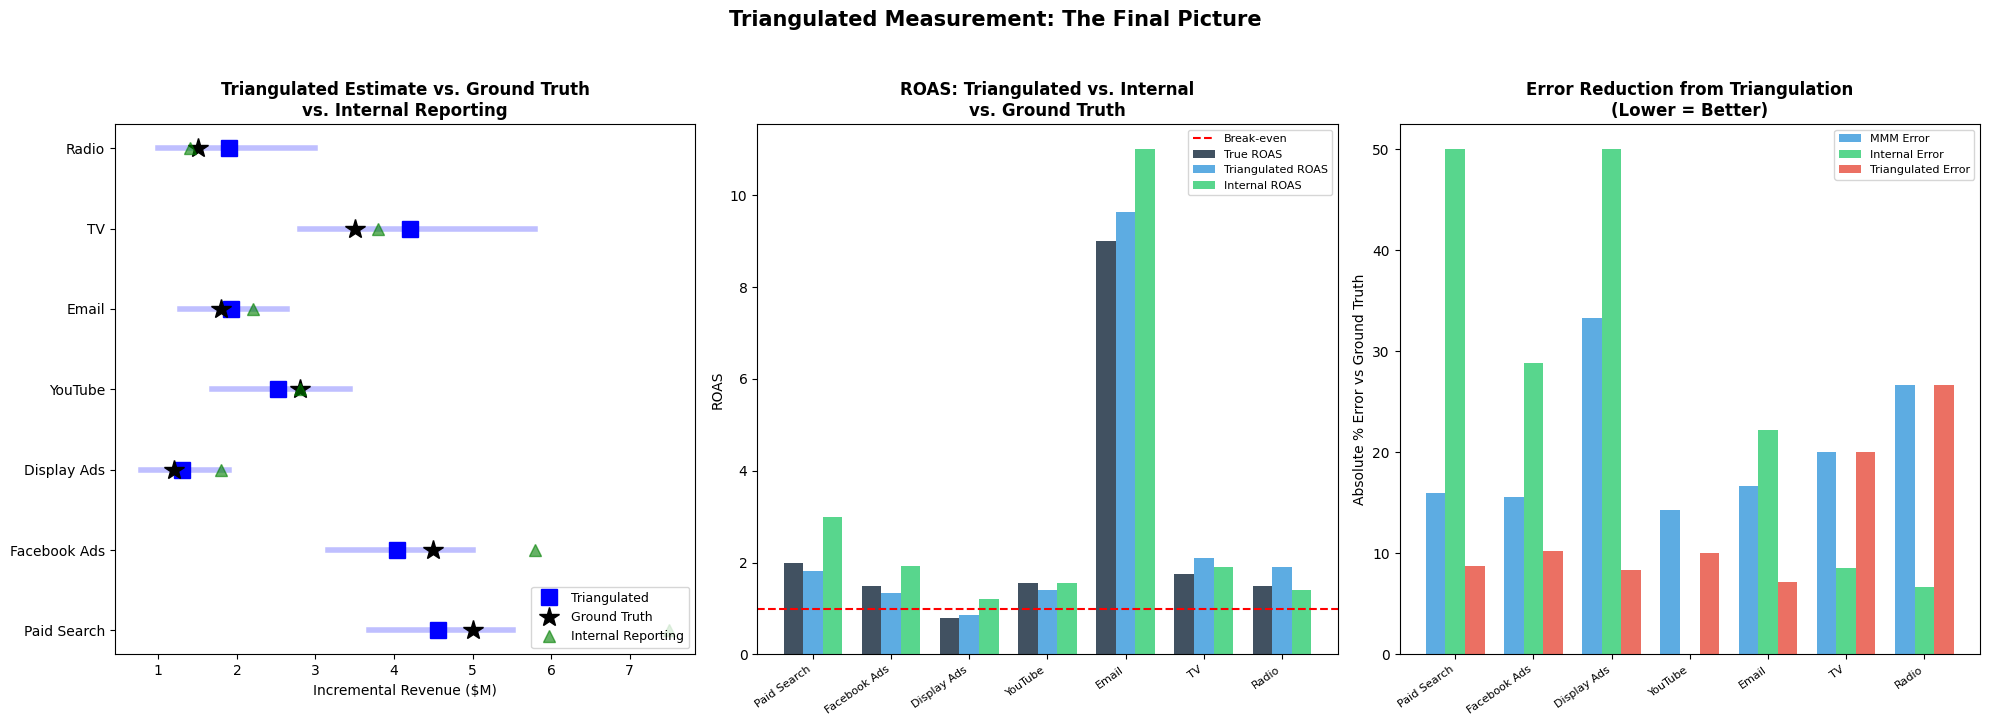

In [10]:
# ============================================================================
# FINAL VISUALIZATION: The Triangulated View
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Triangulated Measurement: The Final Picture',
             fontsize=15, fontweight='bold', y=1.03)

# --- Plot 1: Triangulated Estimate with CI vs Ground Truth ---
ax1 = axes[0]
y_pos = np.arange(len(channels))

for i, channel in enumerate(channels):
    t = triangulated_df.loc[channel]
    true_val = ground_truth.loc[channel, 'true_incremental_revenue'] / 1e6
    best = t['best_estimate'] / 1e6
    lo = t['ci_lower'] / 1e6
    hi = t['ci_upper'] / 1e6
    
    # CI bar
    ax1.plot([lo, hi], [i, i], 'b-', linewidth=4, alpha=0.25)
    # Best estimate
    ax1.plot(best, i, 'bs', markersize=12, label='Triangulated' if i == 0 else '')
    # Ground truth
    ax1.plot(true_val, i, 'k*', markersize=15, label='Ground Truth' if i == 0 else '')
    # Internal reporting
    internal_val = internal_reporting.loc[channel, 'internal_reported_rev'] / 1e6
    ax1.plot(internal_val, i, 'g^', markersize=9, alpha=0.6, 
             label='Internal Reporting' if i == 0 else '')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(channels)
ax1.set_xlabel('Incremental Revenue ($M)')
ax1.set_title('Triangulated Estimate vs. Ground Truth\nvs. Internal Reporting', fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')

# --- Plot 2: ROAS Comparison (Triangulated vs Internal) ---
ax2 = axes[1]
triang_roas = triangulated_df['roas'].astype(float)
internal_roas = internal_reporting['internal_reported_rev'] / ground_truth['spend']
true_roas = ground_truth['true_roas']

x = np.arange(len(channels))
width = 0.25

ax2.bar(x - width, true_roas, width, label='True ROAS', color='#2c3e50', alpha=0.9)
ax2.bar(x, triang_roas, width, label='Triangulated ROAS', color='#3498db', alpha=0.8)
ax2.bar(x + width, internal_roas, width, label='Internal ROAS', color='#2ecc71', alpha=0.8)
ax2.axhline(y=1.0, color='red', linewidth=1.5, linestyle='--', label='Break-even')
ax2.set_xticks(x)
ax2.set_xticklabels(channels, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('ROAS')
ax2.set_title('ROAS: Triangulated vs. Internal\nvs. Ground Truth', fontweight='bold')
ax2.legend(fontsize=8)

# --- Plot 3: Error Reduction from Triangulation ---
ax3 = axes[2]
errors_mmm = []
errors_internal = []
errors_triang = []

for channel in channels:
    true_rev = ground_truth.loc[channel, 'true_incremental_revenue']
    errors_mmm.append(abs(mmm_results.loc[channel, 'mmm_revenue'] - true_rev) / true_rev * 100)
    errors_internal.append(abs(internal_reporting.loc[channel, 'internal_reported_rev'] - true_rev) / true_rev * 100)
    errors_triang.append(abs(triangulated_df.loc[channel, 'best_estimate'] - true_rev) / true_rev * 100)

x = np.arange(len(channels))
width = 0.25

ax3.bar(x - width, errors_mmm, width, label='MMM Error', color='#3498db', alpha=0.8)
ax3.bar(x, errors_internal, width, label='Internal Error', color='#2ecc71', alpha=0.8)
ax3.bar(x + width, errors_triang, width, label='Triangulated Error', color='#e74c3c', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(channels, rotation=35, ha='right', fontsize=8)
ax3.set_ylabel('Absolute % Error vs Ground Truth')
ax3.set_title('Error Reduction from Triangulation\n(Lower = Better)', fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

---

# Section 8: Communicating Conflicting Numbers to Stakeholders

## 8.1 The Stakeholder Challenge

You have 7 channels and 4+ different numbers for each channel. Your VP of Marketing asks: *"So what's our Facebook ROAS?"*

If you say "it depends on the model," you lose credibility.
If you give a single number without context, you're misleading them.

Navigating this tension is an art.

## 8.2 The Communication Framework

### Rule 1: Lead with the Recommendation, Not the Methodology
❌ "Our Markov chain attribution model using first-order transition matrices with removal effects shows..."

✅ "Facebook is our second most efficient channel with a ROAS of 1.5. Here's how confident we are and what we recommend."

### Rule 2: Present a Range, Anchored on the Best Source
❌ "MMM says $4.2M, platform says $6.5M, experiments say $4.2M"

✅ "Facebook drove $4.0-5.0M in incremental revenue (best estimate: $4.2M), validated by our Q2 conversion lift study"

### Rule 3: Explain Platform Discrepancies Proactively
Don't wait for someone to ask "why doesn't this match our Facebook dashboard?"

✅ "You'll notice Meta Ads Manager shows $6.5M — that's because it includes view-through conversions, doesn't deduplicate with Google, and uses a different attribution window. Our number strips those inflations out."

### Rule 4: Use the "Agree-Disagree" Framework
When presented with a number that contradicts yours:

1. **Agree** with the factual observation: "You're right that Meta reports $6.5M"
2. **Bridge** to the context: "That's their methodology, which includes X, Y, Z that inflate the number"
3. **Land** on your recommendation: "When we account for those factors, the true incremental impact is closer to $4.2M"

### Rule 5: Build Credibility Incrementally
Quarter 1: "Here's our MMM — it disagrees with platforms on some channels"
Quarter 2: "We ran an experiment on Facebook and it validated our MMM estimate"
Quarter 3: "Based on our validated model, we recommend reallocating $X to Y"
Quarter 4: "After reallocation, we saw Z% improvement — our model was right"

This is a **multi-quarter trust-building process**, not a single presentation.

In [11]:
# ============================================================================
# GENERATE: Executive Summary Report (What You'd Present to Leadership)
# ============================================================================

def generate_executive_summary(triangulated_df, ground_truth, experiment_results,
                               internal_reporting):
    """
    Generate a formatted executive summary that a staff data scientist
    would present to marketing leadership.
    """
    total_spend = ground_truth['spend'].sum()
    total_triang_rev = triangulated_df['best_estimate'].astype(float).sum()
    blended_roas = total_triang_rev / total_spend
    
    print("=" * 80)
    print(" MARKETING MEASUREMENT — QUARTERLY EXECUTIVE SUMMARY")
    print(f" Period: Q4 2024 | Prepared by: Data Science Team")
    print("=" * 80)
    
    print(f"""
OVERVIEW
{'─'*60}
Total Marketing Spend:        ${total_spend/1e6:>8.1f}M
Estimated Incremental Revenue: ${total_triang_rev/1e6:>8.1f}M
Blended ROAS:                  {blended_roas:>8.2f}
Methodology:                   Triangulated (MMM + MTA + Experiments)
""")
    
    print(f"CHANNEL PERFORMANCE (Ranked by ROAS)")
    print(f"{'─'*75}")
    print(f"{'Channel':<16s} {'Spend':>10s} {'Incr. Rev':>12s} {'ROAS':>7s} "
          f"{'Confidence':>12s} {'Recommendation'}")
    print(f"{'─'*75}")
    
    # Sort by ROAS
    sorted_channels = triangulated_df.sort_values('roas', ascending=False).index
    
    for channel in sorted_channels:
        t = triangulated_df.loc[channel]
        spend = ground_truth.loc[channel, 'spend']
        roas = float(t['roas'])
        
        # Recommendation based on ROAS
        if roas > 2.5:
            rec = "→ INCREASE SPEND"
        elif roas > 1.5:
            rec = "→ Maintain/Test increase"
        elif roas > 1.0:
            rec = "→ Optimize efficiency"
        else:
            rec = "→ INVESTIGATE/REDUCE"
        
        print(f"  {channel:<14s} ${spend/1e6:>7.1f}M ${float(t['best_estimate'])/1e6:>9.1f}M "
              f"{roas:>6.2f} {t['confidence']:>12s}  {rec}")
    
    print(f"""
\nKEY FINDINGS
{'─'*60}""")
    
    # Find best and worst
    best_ch = triangulated_df['roas'].astype(float).idxmax()
    worst_ch = triangulated_df['roas'].astype(float).idxmin()
    
    print(f"""
1. HIGHEST ROAS: {best_ch} at {float(triangulated_df.loc[best_ch, 'roas']):.2f}x
   → Opportunity to increase spend; not yet at saturation

2. LOWEST ROAS: {worst_ch} at {float(triangulated_df.loc[worst_ch, 'roas']):.2f}x
   → Needs efficiency audit; may be over-invested

3. CALIBRATION STATUS: 
   → {len(experiment_results)} channels calibrated with experiments this quarter
   → {len(ground_truth) - len(experiment_results)} channels rely on MMM estimates only
   → Recommend running experiments on {', '.join([ch for ch in ground_truth.index if ch not in experiment_results.index][:2])} next quarter
""")
    
    print(f"DISCREPANCY NOTES (vs. Platform Reporting)")
    print(f"{'─'*60}")
    
    for channel in sorted_channels:
        t = triangulated_df.loc[channel]
        gap = float(t['vs_internal_pct'])
        if abs(gap) > 10:
            direction = "higher" if gap > 0 else "lower"
            print(f"  • {channel}: Our estimate is {abs(gap):.0f}% {direction} than "
                  f"internal dashboards")
            if gap < -20:
                print(f"    Reason: Internal reporting includes view-throughs / "
                      f"no deduplication")
    
    print(f"""
\nMETHODOLOGY NOTE
{'─'*60}
Estimates combine: Marketing Mix Model (Bayesian, weekly data), 
Multi-Touch Attribution (Markov chain, user-level), and 
Incrementality Experiments (geo-lift, conversion lift studies).

Channels with experiments (HIGH confidence): {', '.join(experiment_results.index.tolist())}
Channels without experiments (MODERATE/LOW): {', '.join([ch for ch in ground_truth.index if ch not in experiment_results.index])}

For questions about methodology or to request additional experiments,
contact the measurement team.
""")

generate_executive_summary(triangulated_df, ground_truth, 
                           experiment_results, internal_reporting)

 MARKETING MEASUREMENT — QUARTERLY EXECUTIVE SUMMARY
 Period: Q4 2024 | Prepared by: Data Science Team

OVERVIEW
────────────────────────────────────────────────────────────
Total Marketing Spend:        $    12.0M
Estimated Incremental Revenue: $    20.4M
Blended ROAS:                      1.70
Methodology:                   Triangulated (MMM + MTA + Experiments)

CHANNEL PERFORMANCE (Ranked by ROAS)
───────────────────────────────────────────────────────────────────────────
Channel               Spend    Incr. Rev    ROAS   Confidence Recommendation
───────────────────────────────────────────────────────────────────────────
  Email          $    0.2M $      1.9M   9.64     MODERATE  → INCREASE SPEND
  TV             $    2.0M $      4.2M   2.10 LOW-MODERATE  → Maintain/Test increase
  Radio          $    1.0M $      1.9M   1.90 LOW-MODERATE  → Maintain/Test increase
  Paid Search    $    2.5M $      4.6M   1.82         HIGH  → Maintain/Test increase
  YouTube        $    1.8M $      

---

## Section 9: Measurement Maturity Model & Roadmap

Not all organizations are at the same stage. Here's a framework for assessing where you are and building a roadmap to **measurement excellence**.

### The 5 Levels of Marketing Measurement Maturity

| Level | Name | Characteristics | Typical Org |
|-------|------|-----------------|-------------|
| **1** | **Platform-Dependent** | Rely on Google/Meta dashboards; no deduplication | Startup / small team |
| **2** | **Rule-Based Attribution** | Basic MTA (last-click/first-click); single source of truth | Growing company |
| **3** | **Multi-Model** | MMM + MTA running in parallel; some experiments | Established company |
| **4** | **Triangulated** | Multiple models calibrated with experiments; reconciliation process | Mature data team |
| **5** | **Automated Decisioning** | Real-time triangulated estimates drive automated budget allocation | Industry leader |

### Moving Up the Maturity Ladder

**Level 1 → 2:** Implement a basic MTA system (even last-click is better than nothing when you're deduplicating across platforms)

**Level 2 → 3:** Build an MMM alongside your MTA. This gives you the macro vs micro view needed for strategic planning.

**Level 3 → 4:** Start running incrementality experiments. Even 2-3 per year dramatically improves confidence. Build a reconciliation process.

**Level 4 → 5:** Automate the triangulation pipeline. Feed calibrated estimates into budget optimization. Build feedback loops.

> 💡 **Most companies are at Level 2-3.** If you can get to Level 4, you have a genuine competitive advantage.

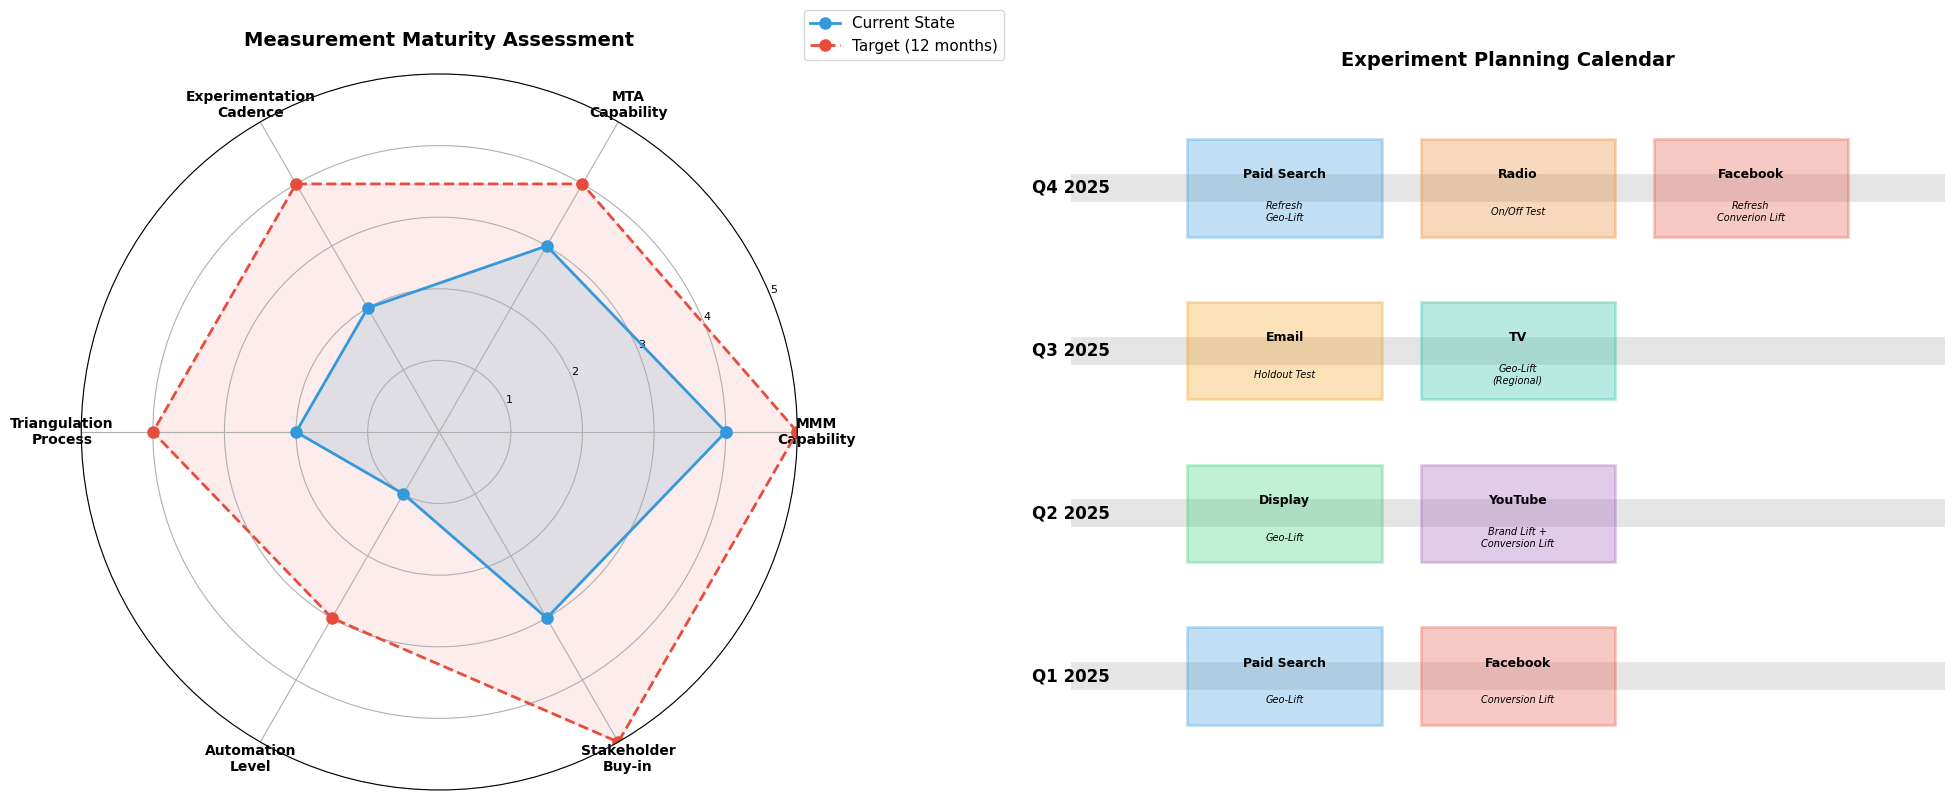


✅ Use this to plan your measurement roadmap and experiment cadence


In [ ]:
# ============================================================================
# VISUALIZATION: Measurement Maturity Assessment & Experiment Planning Calendar
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- LEFT: Maturity Radar Chart ---
ax1 = fig.add_subplot(121, polar=True)
axes[0].set_visible(False)

categories = [
    'MMM\nCapability', 'MTA\nCapability', 'Experimentation\nCadence',
    'Triangulation\nProcess', 'Automation\nLevel', 'Stakeholder\nBuy-in'
]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Current state (example: Level 3 org)
current = [4, 3, 2, 2, 1, 3]
current += current[:1]

# Target state (Level 4)
target = [5, 4, 4, 4, 3, 5]
target += target[:1]

ax1.plot(angles, current, 'o-', linewidth=2, label='Current State', 
         color='#3498db', markersize=8)
ax1.fill(angles, current, alpha=0.15, color='#3498db')
ax1.plot(angles, target, 'o--', linewidth=2, label='Target (12 months)', 
         color='#e74c3c', markersize=8)
ax1.fill(angles, target, alpha=0.1, color='#e74c3c')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])
ax1.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax1.set_title('Measurement Maturity Assessment', fontsize=14, fontweight='bold', pad=20)

# --- RIGHT: Experiment Planning Calendar ---
ax2 = axes[1]

# Plan experiments for next 4 quarters
quarters = ['Q1 2025', 'Q2 2025', 'Q3 2025', 'Q4 2025']
experiments = {
    'Q1 2025': [
        ('Paid Search', 'Geo-Lift', '#3498db'),
        ('Facebook', 'Conversion Lift', '#e74c3c'),
    ],
    'Q2 2025': [
        ('Display', 'Geo-Lift', '#2ecc71'),
        ('YouTube', 'Brand Lift +\nConversion Lift', '#9b59b6'),
    ],
    'Q3 2025': [
        ('Email', 'Holdout Test', '#f39c12'),
        ('TV', 'Geo-Lift\n(Regional)', '#1abc9c'),
    ],
    'Q4 2025': [
        ('Paid Search', 'Refresh\nGeo-Lift', '#3498db'),
        ('Radio', 'On/Off Test', '#e67e22'),
        ('Facebook', 'Refresh\nConverion Lift', '#e74c3c')
    ]
}

for i, quarter in enumerate(quarters):
    ax2.axhline(y=i, color='gray', linestyle='-', alpha=0.2, linewidth=20)
    ax2.text(-0.3, i, quarter, fontsize=12, fontweight='bold', va='center', ha='right')
    
    for j, (channel, exp_type, color) in enumerate(experiments[quarter]):
        x_pos = j * 1.2 + 0.5
        ax2.add_patch(plt.Rectangle((x_pos - 0.4, i - 0.3), 1.0, 0.6, 
                                     facecolor=color, alpha=0.3, 
                                     edgecolor=color, linewidth=2,
                                     zorder=3))
        ax2.text(x_pos + 0.1, i + 0.08, channel, fontsize=9, fontweight='bold',
                va='center', ha='center', zorder=4)
        ax2.text(x_pos + 0.1, i - 0.15, exp_type, fontsize=7,
                va='center', ha='center', style='italic', zorder=4)

ax2.set_xlim(-0.5, 4)
ax2.set_ylim(-0.7, 3.7)
ax2.set_title('Experiment Planning Calendar', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Use this to plan your measurement roadmap and experiment cadence")

---

## Section 10: Final Summary — The Complete Triangulation Playbook

### What We Covered

| Section | Key Takeaway |
|---------|-------------|
| **1. Why Triangulation** | No single model captures the full truth. You need multiple lenses. |
| **2. The Measurement Ecosystem** | Comparing results across MMM, MTA, experiments, and platform reports reveals where each is strong/weak. |
| **3. MMM ↔ MTA Mapping** | MMM captures top-of-funnel/offline; MTA captures mid/bottom-funnel digital. Trust each where they're strongest. |
| **4. Calibrating with Experiments** | Incrementality experiments are the "ground truth anchor" — use them to calibrate other models via Bayesian priors. |
| **5. Model vs Internal Reporting** | Gaps are EXPECTED. The question isn't "who's right" but "why do they differ" and "what's the true incremental impact?" |
| **6. Reconciliation Playbook** | A structured 5-step process produces a single best estimate per channel with confidence levels. |
| **7. Communication Framework** | Present ranges, not points. Lead with areas of agreement. Let experiments settle arguments. |
| **8. Maturity Model** | Most orgs are at Level 2-3. Getting to Level 4 (calibrated triangulation) is a genuine competitive advantage. |

### The Three Laws of Marketing Measurement

1. **All models are wrong, but some are useful** — Your job isn't to find the "right" number, but to make better decisions than you would with no model at all.

2. **Triangulation beats precision** — Three imperfect estimates that agree are worth more than one "precise" estimate you can't validate.

3. **Experiments are the tiebreaker** — When MMM and MTA disagree, don't argue — run an experiment.

### The Data Scientist's Measurement Checklist

Use the code cell below to print your comprehensive implementation checklist.

---

### Congratulations!

You've completed the **Marketing Measurement Triangulation Guide** — the third and final notebook in this series.

**The Complete Series:**
1. **MMM_Complete_Guide** — Marketing Mix Modeling from zero to expert
2. **MMA_Complete_Guide** — Multi-Touch Attribution from zero to expert  
3. **Triangulation_Guide** (this notebook) — Unifying everything with calibration and reconciliation

Together, these three notebooks give you the full toolkit a **Data Scientist** needs to lead marketing measurement at any organization. You can now:

- Build and diagnose an MMM
- Implement multiple attribution models (rule-based, Markov, Shapley)
- Design and analyze incrementality experiments
- Triangulate across methodologies
- Reconcile when models disagree with internal reporting
- Communicate results to non-technical stakeholders
- Build a measurement maturity roadmap

> *"The goal of marketing measurement isn't to be right — it's to be less wrong over time, and to make decisions that are better than the alternative."*

In [13]:
# ============================================================================
# FINAL: Comprehensive Implementation Checklist
# ============================================================================

def print_measurement_checklist():
    """The ultimate checklist for a Staff DS leading marketing measurement."""
    
    checklist = {
        "🏗️ FOUNDATION (Month 1-2)": [
            ("Audit current measurement stack", 
             "What models exist? What data is available? What decisions are being made with what data?"),
            ("Map the data landscape", 
             "Identify all data sources: ad platforms, analytics, CRM, offline, experiments"),
            ("Assess measurement maturity level", 
             "Use the 5-level framework from Section 9"),
            ("Document known biases per platform", 
             "E.g., Meta over-reports by ~30% due to view-throughs, last-click under-values awareness"),
            ("Build stakeholder alignment", 
             "Get marketing leadership to agree on goals BEFORE showing numbers"),
        ],
        "📊 MMM SETUP (Month 2-4)": [
            ("Collect 2+ years of weekly data", 
             "Spend, impressions, revenue/conversions, macro factors, seasonality"),
            ("Implement adstock + saturation transforms", 
             "See MMM_Complete_Guide Sections 5-6"),
            ("Build Bayesian MMM", 
             "Prefer Bayesian over frequentist for uncertainty quantification"),
            ("Validate with known events", 
             "Did the model capture that campaign pause? That holiday spike?"),
            ("Generate channel contribution estimates", 
             "Base + incremental per channel with confidence intervals"),
        ],
        "🔗 MTA SETUP (Month 3-5)": [
            ("Build user journey data pipeline", 
             "Touchpoint-level data with timestamps and unique user IDs"),
            ("Implement Markov chain attribution", 
             "Captures channel interactions and synergies — see MMA_Complete_Guide Section 5"),
            ("Handle cross-device/identity", 
             "Deterministic matching + probabilistic fallback"),
            ("Validate with holdout experiments", 
             "Attribution says X channel is valuable — does removing it actually drop conversions?"),
            ("Build real-time dashboard", 
             "For tactical day-to-day optimization by marketing managers"),
        ],
        "🧪 EXPERIMENTATION PROGRAM (Month 4-6)": [
            ("Run first geo-lift experiment", 
             "Pick your highest-spend channel; 3-4 week test + 1-2 week cooldown"),
            ("Set up conversion lift studies", 
             "Partner with Meta/Google for platform-native experiments"),
            ("Build experiment planning calendar", 
             "Aim for 4-6 experiments per year, rotating across channels"),
            ("Document lift estimates", 
             "These become your 'ground truth' anchors for calibration"),
            ("Create experiment ROI framework", 
             "Show leadership the value of the information gained vs. the cost of running tests"),
        ],
        "🔺 TRIANGULATION (Month 6-8)": [
            ("Build comparison dashboard", 
             "Side-by-side view of MMM vs MTA vs Experiments vs Platform reports"),
            ("Implement Bayesian calibration", 
             "Use experiment results as informative priors for MMM — see Section 5 of this notebook"),
            ("Build the reconciliation pipeline", 
             "5-step process from Section 7: Normalize → Compare → Diagnose → Triangulate → Document"),
            ("Create the misalignment diagnostic", 
             "Automated flagging when model vs internal report gaps exceed thresholds"),
            ("Generate triangulated estimates with confidence levels", 
             "HIGH/MODERATE/LOW based on data availability per channel"),
        ],
        "📢 COMMUNICATION & GOVERNANCE (Ongoing)": [
            ("Establish quarterly measurement review cadence", 
             "Present triangulated results to marketing leadership every quarter"),
            ("Create the 'Source of Truth' document", 
             "Which metric to trust for which decision — agreed upon by all stakeholders"),
            ("Build the 'Why Numbers Differ' FAQ", 
             "Pre-answer the inevitable questions about conflicting reports"),
            ("Train marketing managers on measurement literacy", 
             "They don't need to understand Bayesian stats, but they need to understand 'why MMM ≠ Google Ads'"),
            ("Document all assumptions and limitations", 
             "Intellectual honesty builds trust faster than false precision"),
        ],
    }
    
    total_items = sum(len(items) for items in checklist.values())
    print("=" * 80)
    print(" MARKETING MEASUREMENT — IMPLEMENTATION CHECKLIST")
    print(f" {total_items} items across {len(checklist)} phases")
    print("=" * 80)
    
    for phase, items in checklist.items():
        print(f"\n{phase}")
        print("─" * 70)
        for i, (task, detail) in enumerate(items, 1):
            print(f"  {'☐'} {task}")
            print(f"       {detail}")
        print()
    
    print("=" * 80)
    print(" MEASUREMENT DECISION MATRIX (Quick Reference)")
    print("=" * 80)
    print(f"""
┌──────────────────────────┬─────────────┬────────────┬──────────────┐
│ Decision                 │ Primary     │ Validate   │ Calibrate    │
│                          │ Source      │ With       │ Using        │
├──────────────────────────┼─────────────┼────────────┼──────────────┤
│ Annual budget allocation │ MMM         │ Experiments│ Geo-lift     │
│ Channel mix optimization │ MMM         │ MTA        │ Experiments  │
│ Campaign-level ROAS      │ MTA         │ Platform   │ MMM trends   │
│ Creative performance     │ MTA/Platform│ A/B tests  │ —            │
│ New channel investment   │ Experiments │ MMM (later)│ —            │
│ Diminishing returns      │ MMM         │ Experiments│ Saturation   │
│ Cross-channel synergies  │ MMM         │ Markov MTA │ —            │
│ Real-time bid adjustment │ MTA/Platform│ —          │ Lift studies │
│ Brand vs Performance mix │ MMM         │ Brand lift │ Surveys      │
│ CFO reporting            │ Triangulated│ —          │ All methods  │
└──────────────────────────┴─────────────┴────────────┴──────────────┘
""")
    
    print("🎉 You now have everything you need to build a world-class")
    print("   marketing measurement program. Go make better decisions!")

print_measurement_checklist()

 MARKETING MEASUREMENT — IMPLEMENTATION CHECKLIST
 30 items across 6 phases

🏗️ FOUNDATION (Month 1-2)
──────────────────────────────────────────────────────────────────────
  ☐ Audit current measurement stack
       What models exist? What data is available? What decisions are being made with what data?
  ☐ Map the data landscape
       Identify all data sources: ad platforms, analytics, CRM, offline, experiments
  ☐ Assess measurement maturity level
       Use the 5-level framework from Section 9
  ☐ Document known biases per platform
       E.g., Meta over-reports by ~30% due to view-throughs, last-click under-values awareness
  ☐ Build stakeholder alignment
       Get marketing leadership to agree on goals BEFORE showing numbers


📊 MMM SETUP (Month 2-4)
──────────────────────────────────────────────────────────────────────
  ☐ Collect 2+ years of weekly data
       Spend, impressions, revenue/conversions, macro factors, seasonality
  ☐ Implement adstock + saturation transforms
   